In [1]:
import os
import pickle
import pandas as pd
    
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# directory of CSV files
shap_directory = "/home/guillen/Conference Paper SHAP Maciej actualizado/Mammography/shap"

parquet_directory = "/home/guillen/Conference Paper SHAP Maciej actualizado/Mammography/shap"

scoringResults_directory = ""

sorted_orderScore = pd.DataFrame()

In [3]:
sorted_orderScore = []

In [4]:
sorted_orderScore = pd.read_csv(scoringResults_directory+"shap_orderScore_rf.csv")

In [5]:
sorted_orderScore.drop("Unnamed: 0",axis=1,inplace = True)

In [6]:
sorted_orderScore

,imbalanceRatio,Subset,Indicator,Sorted_Features
0,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,orderMean,"['X4', 'X5', 'X6', 'X2', 'X1', 'X3']"
1,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,orderStd,"['X4', 'X6', 'X5', 'X3', 'X2', 'X1']"
2,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,orderSum,"['X4', 'X5', 'X6', 'X2', 'X1', 'X3']"
3,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_88,orderMean,"['X4', 'X5', 'X6', 'X3', 'X1', 'X2']"
4,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_88,orderStd,"['X4', 'X5', 'X3', 'X6', 'X2', 'X1']"
...,...,...,...,...
2215,rf_shap_list_ir_2,rf_shap_list_ir_2_subset_7,orderStd,"['X5', 'X4', 'X2', 'X3', 'X1', 'X6']"
2216,rf_shap_list_ir_2,rf_shap_list_ir_2_subset_7,orderSum,"['X4', 'X5', 'X1', 'X2', 'X6', 'X3']"
2217,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_41,orderMean,"['X4', 'X5', 'X6', 'X3', 'X2', 'X1']"
2218,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_41,orderStd,"['X4', 'X5', 'X3', 'X2', 'X6', 'X1']"


In [7]:
sorted_orderScore["Sorted_Features"][0]

"['X4', 'X5', 'X6', 'X2', 'X1', 'X3']"

## Max density values

SHAP value for max KDE (for each feature) - to change, right now its max bar from histogram, a bit generalized maxShap 

In [8]:
maxDensityValues = pd.read_csv(scoringResults_directory+"shap_maxDensityValues_rf.csv")
maxDensityValues.drop("Unnamed: 0",axis=1,inplace = True)

In [9]:
maxDensityValues[:10]

,imbalanceRatio,Subset,feature,Indicator,freq1,freq2,freq3
0,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,X1,localMax_X1,0.035389,0.058584,0.046986
1,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,X2,localMax_X2,0.045169,0.061928,0.028410
2,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,X3,localMax_X3,-0.015124,0.054116,0.042576
3,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,X4,localMax_X4,0.116989,0.141203,0.165418
4,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,X5,localMax_X5,0.067436,0.086502,0.105567
5,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,X6,localMax_X6,0.102326,0.126988,0.003679
6,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_88,X1,localMax_X1,0.070938,0.030086,0.050512
7,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_88,X2,localMax_X2,0.011314,0.029373,0.047431
8,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_88,X3,localMax_X3,-0.023224,0.098422,-0.005846
9,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_88,X4,localMax_X4,0.143338,0.179580,-0.037873


In [10]:
maxDensityValues.columns

Index(['imbalanceRatio', 'Subset', 'feature', 'Indicator', 'freq1', 'freq2',
       'freq3'],
      dtype='object')

In [11]:
maxDensityValues[['imbalanceRatio', 'feature', 'freq1']]

,imbalanceRatio,feature,freq1
0,rf_shap_list_ir_1,X1,0.035389
1,rf_shap_list_ir_1,X2,0.045169
2,rf_shap_list_ir_1,X3,-0.015124
3,rf_shap_list_ir_1,X4,0.116989
4,rf_shap_list_ir_1,X5,0.067436
...,...,...,...
4435,rf_shap_list_ir_3,X2,0.082772
4436,rf_shap_list_ir_3,X3,-0.041033
4437,rf_shap_list_ir_3,X4,0.180536
4438,rf_shap_list_ir_3,X5,0.055879


In [12]:
# Group by 'imbalanceRatio' and compute statistics for 'freq1'
freq1Statistics = (
    maxDensityValues.groupby(["imbalanceRatio", 'feature'])
    .agg(
        median=("freq1", "median"),
        mean=("freq1", "mean"),
        std=("freq1", "std"),
        iqr=("freq1", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )
)

In [13]:
freq1Statistics.reset_index(inplace=True)

In [14]:
df_melted = freq1Statistics.melt(id_vars=["imbalanceRatio"], var_name="Statistic", value_name="Value")

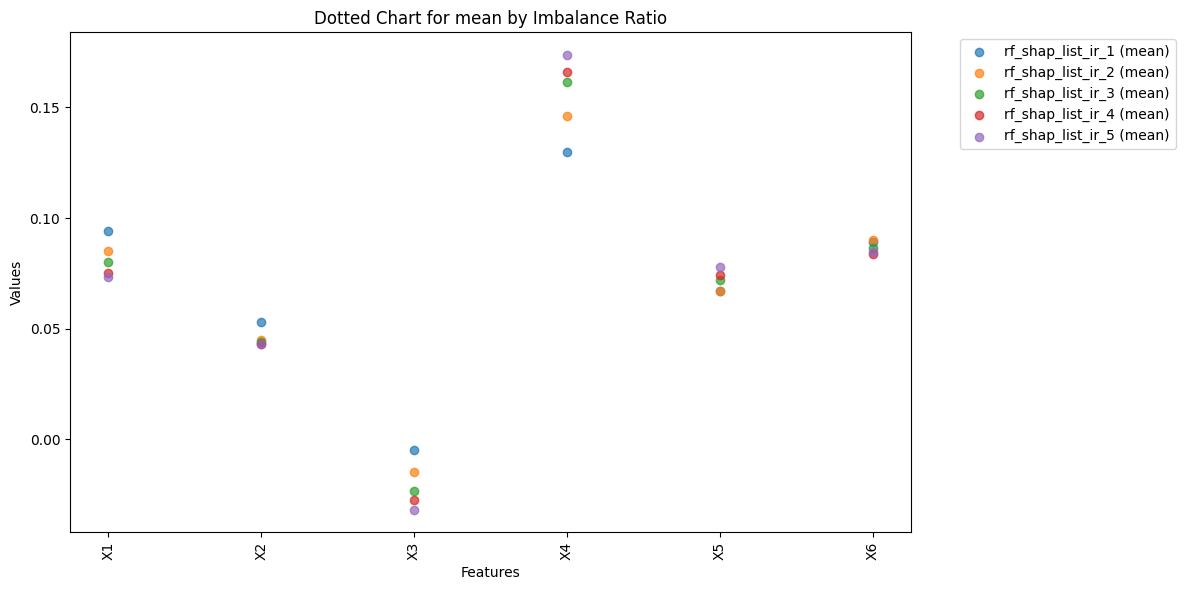

In [15]:
# Reset index to prepare for plotting
df_reset = freq1Statistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalanceRatio"].unique():
    subset = df_reset[df_reset["imbalanceRatio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)  # median chart
    plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)  # mean chart
#     plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)  # std chart
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)  # iqr chart

plt.xticks(rotation=90)
plt.title("Dotted Chart for mean by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

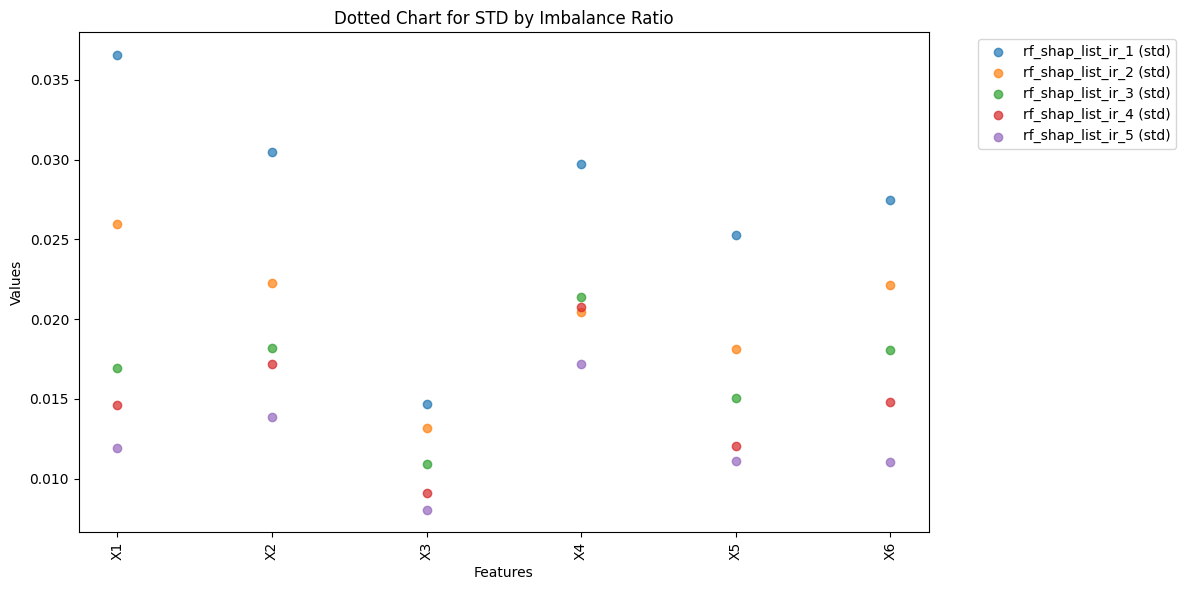

In [16]:
# Reset index to prepare for plotting
df_reset = freq1Statistics.reset_index()

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalanceRatio"].unique():
    subset = df_reset[df_reset["imbalanceRatio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
    plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for STD by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

IR1 - 2%
IR2 - 5%
IR5 - 20%

-- STD results are proportional/similar to IQR
-- Lower Imbalance ratio, the model provides better consistency regarding XAI results. STD is 2x lower than for IR 1
    -- it is true especially for the most important features, these one have the most differences between the IR
    
-- If the mean is similar between IR, and std is different. It means that model is aiming at the same values, hovewer is getting more confused/mistaken with growing IR 

***
***
***
## Mean SHAP

In [17]:
sorted_orderValuesScore = []
sorted_orderValuesScore = pd.read_csv(scoringResults_directory+"sorted_orderValuesScore_rf.csv")
sorted_orderValuesScore.drop("Unnamed: 0",axis=1,inplace = True)
sorted_orderValuesScore.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

In [18]:
sorted_orderValuesScore

,feature,shapMean,shapStd,shapSum,subset,imbalance_ratio
0,X1,0.044782,0.017896,46.572773,rf_shap_list_ir_1_subset_35,rf_shap_list_ir_1
1,X2,0.057207,0.026887,59.495373,rf_shap_list_ir_1_subset_35,rf_shap_list_ir_1
2,X3,0.041808,0.031034,43.480790,rf_shap_list_ir_1_subset_35,rf_shap_list_ir_1
3,X4,0.126551,0.059158,131.612892,rf_shap_list_ir_1_subset_35,rf_shap_list_ir_1
4,X5,0.098439,0.043597,102.376890,rf_shap_list_ir_1_subset_35,rf_shap_list_ir_1
...,...,...,...,...,...,...
4435,X2,0.064146,0.045353,66.711492,rf_shap_list_ir_3_subset_41,rf_shap_list_ir_3
4436,X3,0.069019,0.048402,71.779430,rf_shap_list_ir_3_subset_41,rf_shap_list_ir_3
4437,X4,0.157435,0.068780,163.732405,rf_shap_list_ir_3_subset_41,rf_shap_list_ir_3
4438,X5,0.093391,0.051139,97.126141,rf_shap_list_ir_3_subset_41,rf_shap_list_ir_3


In [19]:
# Group by 'imbalanceRatio' and compute statistics for 'shapMean'
meanStatistics = (
    sorted_orderValuesScore.groupby(["imbalance_ratio", 'feature'])
    .agg(
        median=("shapMean", "median"),
        mean=("shapMean", "mean"),
        std=("shapMean", "std"),
        iqr=("shapMean", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )
)
meanStatistics.reset_index(inplace=True)

In [20]:
meanStatistics[:5]

,imbalance_ratio,feature,median,mean,std,iqr
0,rf_shap_list_ir_1,X1,0.075105,0.075657,0.021713,0.026356
1,rf_shap_list_ir_1,X2,0.058423,0.059077,0.013304,0.017099
2,rf_shap_list_ir_1,X3,0.050690,0.052571,0.012800,0.017746
3,rf_shap_list_ir_1,X4,0.126031,0.127476,0.023338,0.035107
4,rf_shap_list_ir_1,X5,0.084189,0.087778,0.028265,0.039227


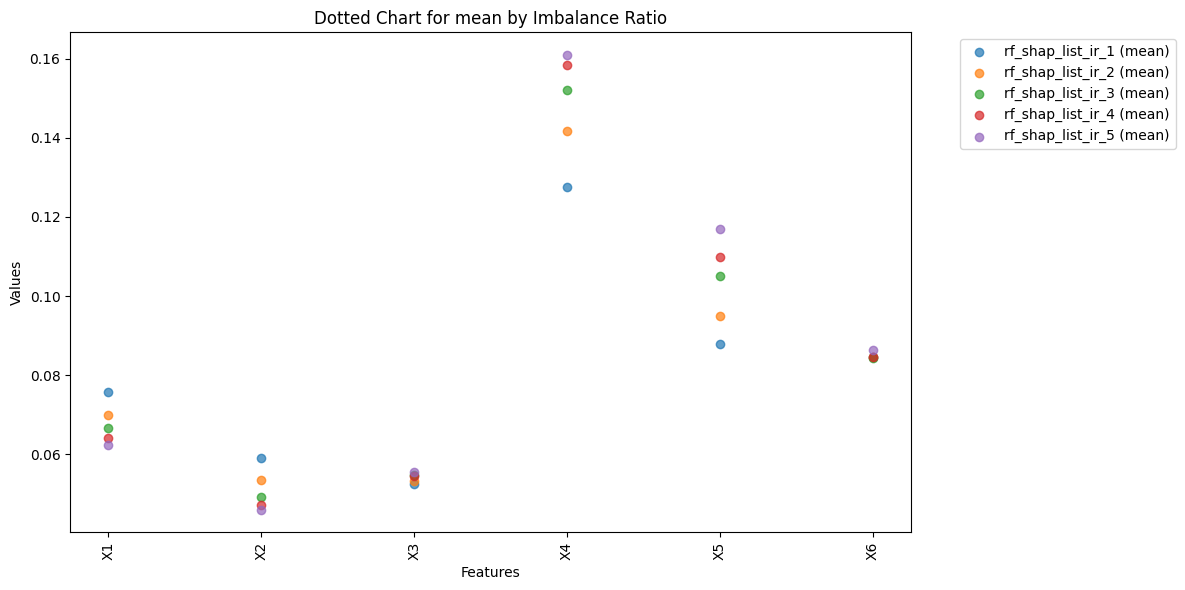

In [21]:
# Reset index to prepare for plotting
df_reset = meanStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)  # median chart
    plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)  # mean chart
#     plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)  # std chart
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)  # iqr chart

plt.xticks(rotation=90)
plt.title("Dotted Chart for mean by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### t-tests

In [22]:
import pandas as pd
import scipy.stats as stats
import itertools

# Load your dataset
sorted_orderValuesScore = pd.read_csv("sorted_orderValuesScore_rf.csv")
sorted_orderValuesScore.drop("Unnamed: 0", axis=1, inplace=True)
sorted_orderValuesScore.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

# Get unique IRs and features
imbalance_ratios = sorted_orderValuesScore['imbalance_ratio'].unique()
features = sorted_orderValuesScore['feature'].unique()

# Dictionary to store rankings
rankings_dict = {feature: {} for feature in features}

for feature in features:
    # Filter data for the feature
    feature_data = sorted_orderValuesScore[sorted_orderValuesScore['feature'] == feature]

    # Compute mean shapMean per IR
    means = feature_data.groupby('imbalance_ratio')['shapMean'].mean().sort_values(ascending=False)
    
    # Initialize significance matrix
    significance_matrix = pd.DataFrame(1.0, index=imbalance_ratios, columns=imbalance_ratios)

    # Pairwise t-tests
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        group1 = feature_data[feature_data['imbalance_ratio'] == ir1]['shapMean']
        group2 = feature_data[feature_data['imbalance_ratio'] == ir2]['shapMean']
        
        if len(group1) > 1 and len(group2) > 1:  # Ensure enough data
            stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)  # Welch’s t-test
        else:
            p_value = 1  # Assume no difference if insufficient data
        
        # Store p-value
        significance_matrix.loc[ir1, ir2] = p_value
        significance_matrix.loc[ir2, ir1] = p_value

    # Assign initial rankings based on means
    ranking_values = {ir: rank + 1 for rank, ir in enumerate(means.index)}

    # Adjust rankings if no significant differences
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        if significance_matrix.loc[ir1, ir2] >= 0.05:  # No significant difference
            min_rank = min(ranking_values[ir1], ranking_values[ir2])
            ranking_values[ir1] = ranking_values[ir2] = min_rank

    rankings_dict[feature] = ranking_values

# Convert to DataFrame
ranking_table = pd.DataFrame(rankings_dict).T.fillna(0)

sorted_columns = sorted(ranking_table.columns, key=lambda x: int(x.split('_')[-1]))

# Reorder the DataFrame
ranking_table = ranking_table[sorted_columns]

# Function to adjust rankings so that ties do not skip numbers
def adjust_rankings(df):
    adjusted_df = df.copy()
    
    for feature in df.index:
        unique_ranks = sorted(set(df.loc[feature]))  # Get unique ranks in sorted order
        rank_mapping = {old_rank: new_rank + 1 for new_rank, old_rank in enumerate(unique_ranks)}  # Map old ranks to new continuous ranks
        
        # Apply mapping to adjust ranks
        adjusted_df.loc[feature] = df.loc[feature].map(rank_mapping)

    return adjusted_df

# Apply the function to adjust rankings
ranking_table = adjust_rankings(ranking_table)
import ace_tools_open as tools
# Display the updated ranking table
tools.display_dataframe_to_user(name="Adjusted Ranking of the mean by IR for shapMeans", dataframe=ranking_table)


Adjusted Ranking of the mean by IR for shapMeans


Loading ITables v2.4.4 from the internet... (need help?)


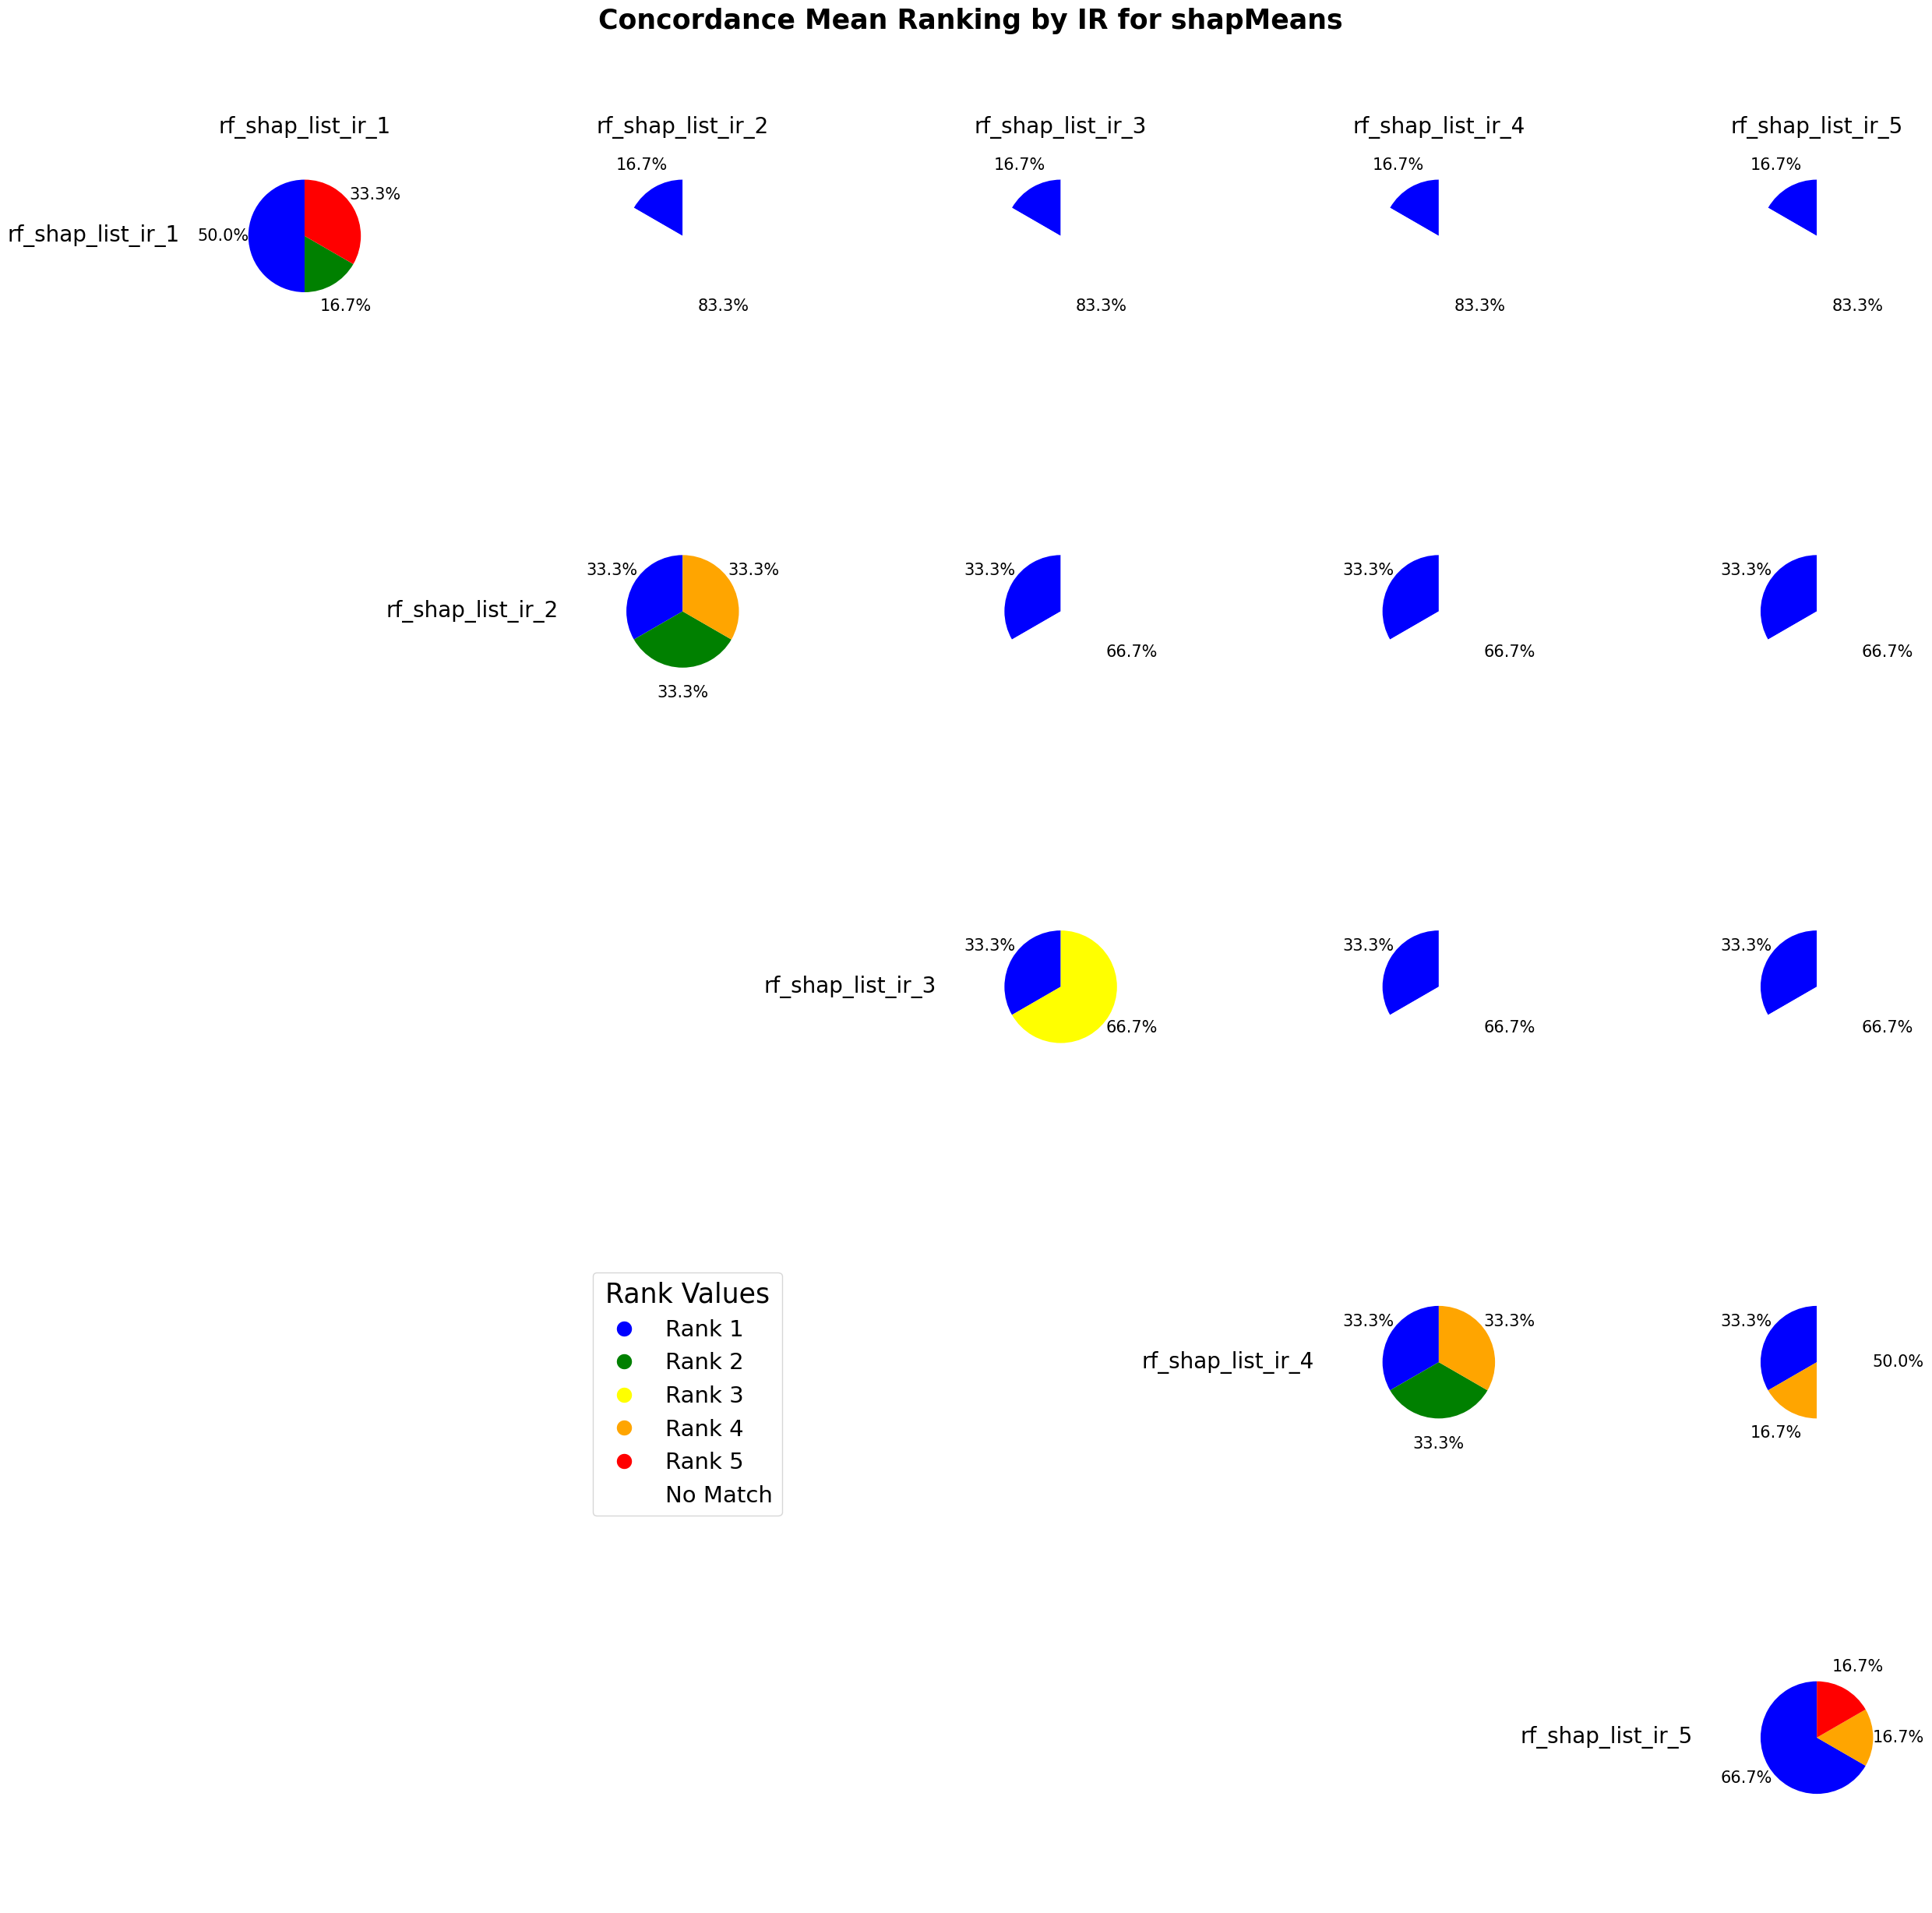

In [23]:
import numpy as np
import matplotlib.pyplot as plt

num_irs = 5
shap_list_labels = [f"rf_shap_list_ir_{j}" for j in range(1, num_irs + 1)]

rank_colors = {1: 'blue', 2: 'green', 3: 'yellow', 4: 'orange', 5: 'red'}
mismatch_color = 'white'  # Color for non-matching ranks

fig, axes = plt.subplots(num_irs, num_irs, figsize=(25, 25))
# Add a general title to the entire plot
fig.suptitle('Concordance Mean Ranking by IR for shapMeans', fontsize=25, fontweight='bold')

num_variables = ranking_table.shape[0]

for i in range(num_irs):
    for j in range(num_irs):
        ax = axes[i, j]

        if j < i:
            ax.axis("off")
            continue

        if i == j:
            values, counts = np.unique(ranking_table.iloc[:, i], return_counts=True)
            colors = [rank_colors[v] for v in values]
        else:
            matching_counts = {rank: 0 for rank in rank_colors.keys()}

            for var in range(num_variables):
                rank_i = ranking_table.iloc[var, i]
                rank_j = ranking_table.iloc[var, j]
                if rank_i == rank_j:
                    matching_counts[rank_i] += 1

            values = [rank for rank, count in matching_counts.items() if count > 0]
            counts = [count / num_variables for rank, count in matching_counts.items() if count > 0]

            mismatch_proportion = 1 - sum(counts)
            if mismatch_proportion > 0:
                values.append(0)
                counts.append(mismatch_proportion)

            colors = [rank_colors.get(v, mismatch_color) for v in values]

        if len(values) > 0:
            ax.pie(counts, labels=None, autopct='%1.1f%%', colors=colors, startangle=90,textprops={'fontsize': 15},pctdistance=1.45)
        else:
            ax.axis("off")

        if j == i:
            ax.set_ylabel(shap_list_labels[i], rotation=0, labelpad=50, fontsize=20, ha='right', va='center')

for ax, col in zip(axes[0], shap_list_labels):
    ax.set_title(col, fontsize=20, pad=30)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=15) for color in rank_colors.values()]
handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=15))  # Ensure "No Match" appears visible in legend

labels = [f"Rank {k}" for k in rank_colors.keys()] + ["No Match"]
fig.legend(handles, labels, title="Rank Values", loc="lower left", bbox_to_anchor=(0.3, 0.2), fontsize=21, title_fontsize=25)
plt.tight_layout()
plt.show()

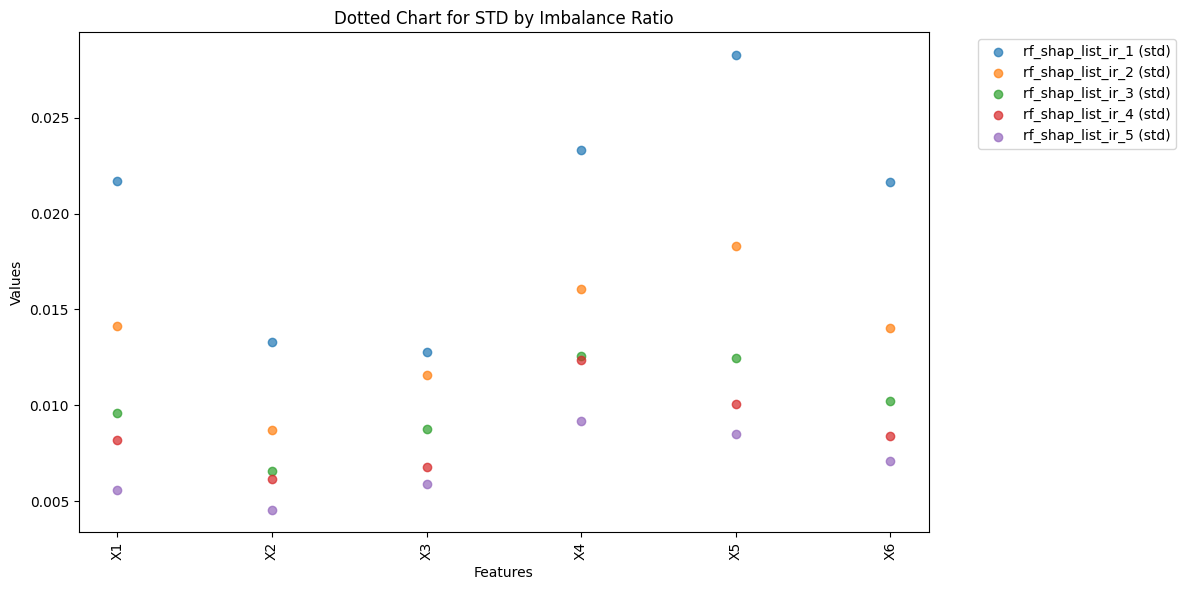

In [24]:
# Reset index to prepare for plotting
df_reset = meanStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
    plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for STD by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import scipy.stats as stats
import itertools

# Load the dataset
sorted_orderValuesScore = pd.read_csv("sorted_orderValuesScore_rf.csv")
sorted_orderValuesScore.drop("Unnamed: 0", axis=1, inplace=True)
sorted_orderValuesScore.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

# Get unique features and imbalance ratios
features = sorted_orderValuesScore['feature'].unique()
imbalance_ratios = sorted_orderValuesScore['imbalance_ratio'].unique()

# Dictionary to store rankings based on standard deviation of shapMean
rankings_std_dict = {feature: {} for feature in features}

for feature in features:
    # Filter data for the feature
    feature_data = sorted_orderValuesScore[sorted_orderValuesScore['feature'] == feature]

    # Compute std deviation of shapMean per IR
    std_devs = feature_data.groupby('imbalance_ratio')['shapMean'].std().sort_values(ascending=False)
    
    # Initialize significance matrix
    significance_matrix = pd.DataFrame(1.0, index=imbalance_ratios, columns=imbalance_ratios)

    # Pairwise Levene's test for variance comparison
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        group1 = feature_data[feature_data['imbalance_ratio'] == ir1]['shapMean']
        group2 = feature_data[feature_data['imbalance_ratio'] == ir2]['shapMean']
        
        if len(group1) > 1 and len(group2) > 1:  # Ensure enough data
            stat, p_value = stats.levene(group1, group2, center='median')  # Levene’s test
        else:
            p_value = 1  # Assume no difference if insufficient data
        
        # Store p-value
        significance_matrix.loc[ir1, ir2] = p_value
        significance_matrix.loc[ir2, ir1] = p_value

    # Assign initial rankings based on standard deviations
    ranking_values = {ir: rank + 1 for rank, ir in enumerate(std_devs.index)}

    # Adjust rankings if no significant differences
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        if significance_matrix.loc[ir1, ir2] >= 0.05:  # No significant difference
            min_rank = min(ranking_values[ir1], ranking_values[ir2])
            ranking_values[ir1] = ranking_values[ir2] = min_rank

    rankings_std_dict[feature] = ranking_values

# Convert to DataFrame
ranking_std_table = pd.DataFrame(rankings_std_dict).T.fillna(0)

# Reorder the columns based on IR numeric values
sorted_columns = sorted(ranking_std_table.columns, key=lambda x: int(x.split('_')[-1]))
ranking_std_table = ranking_std_table[sorted_columns]

# Function to adjust rankings so that ties do not skip numbers
def adjust_rankings(df):
    adjusted_df = df.copy()
    
    for feature in df.index:
        unique_ranks = sorted(set(df.loc[feature]))  # Get unique ranks in sorted order
        rank_mapping = {old_rank: new_rank + 1 for new_rank, old_rank in enumerate(unique_ranks)}  # Map old ranks to new continuous ranks
        
        # Apply mapping to adjust ranks
        adjusted_df.loc[feature] = df.loc[feature].map(rank_mapping)

    return adjusted_df

# Apply the function to adjust rankings
ranking_std_table = adjust_rankings(ranking_std_table)

# Display the updated ranking table
tools.display_dataframe_to_user(name="Adjusted Ranking of the variance by IR for shapMeans", dataframe=ranking_std_table)


Adjusted Ranking of the variance by IR for shapMeans


Loading ITables v2.4.4 from the internet... (need help?)


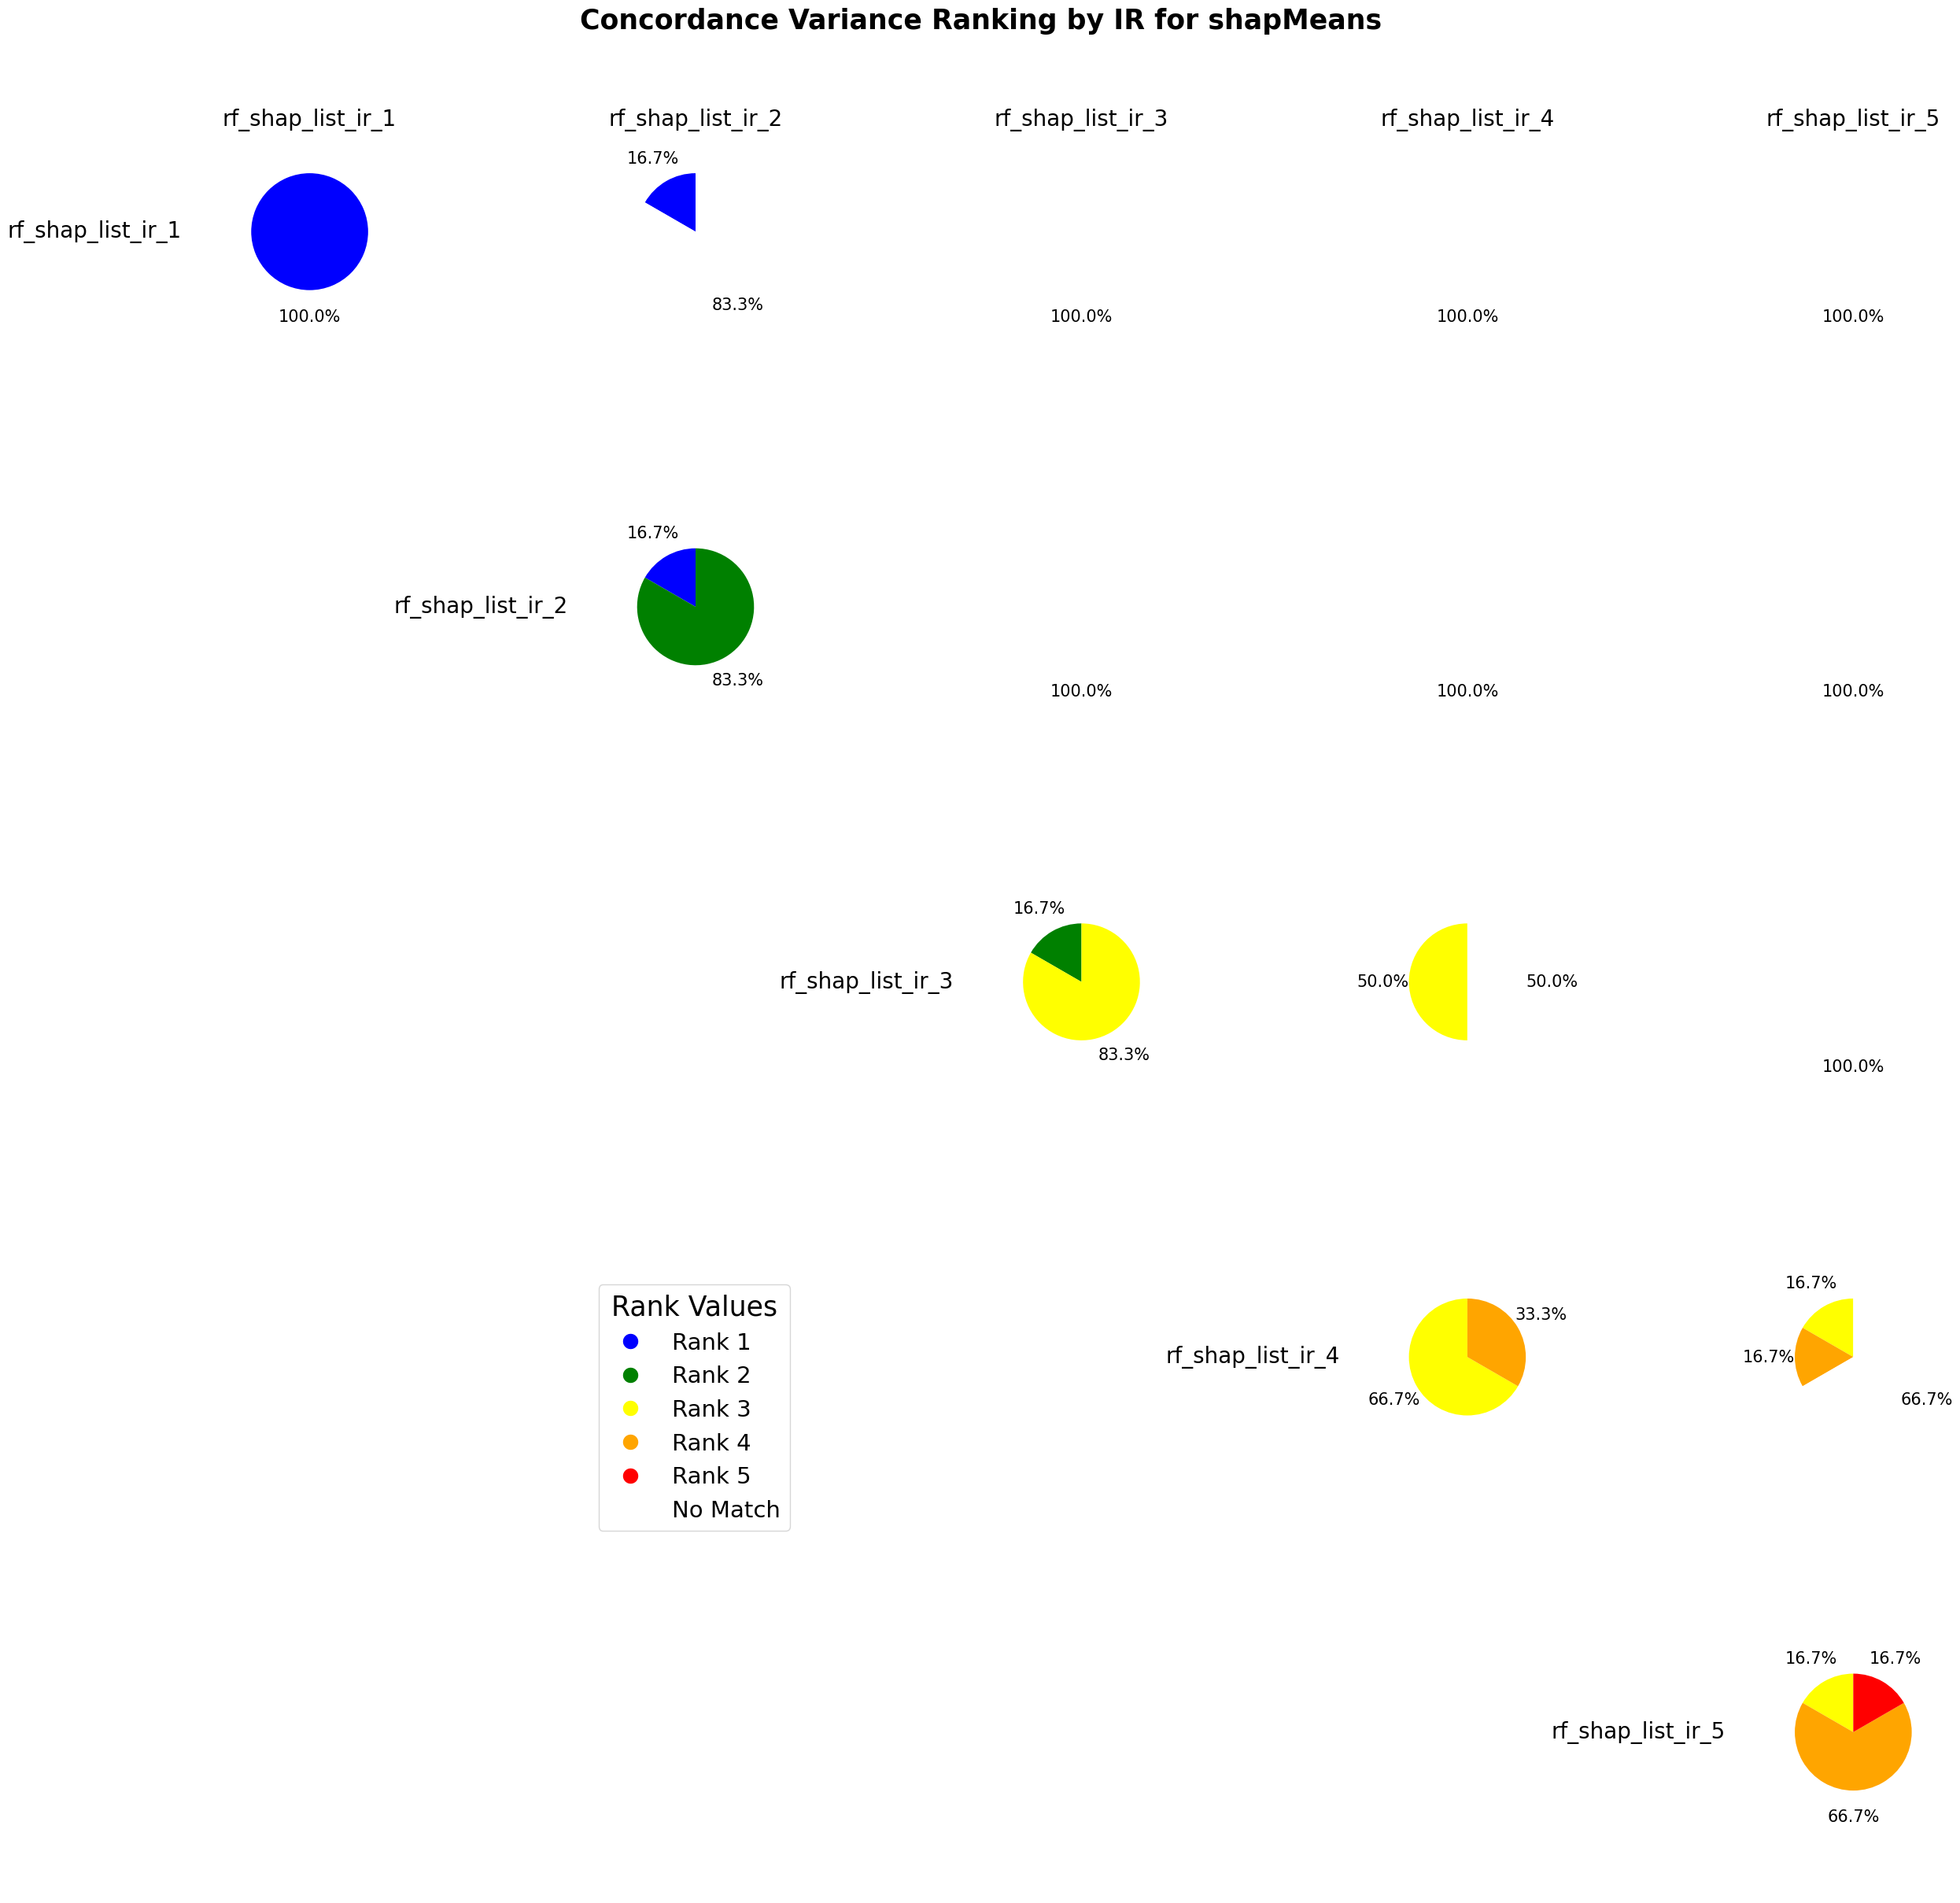

In [26]:
import numpy as np
import matplotlib.pyplot as plt

num_irs = 5
shap_list_labels = [f"rf_shap_list_ir_{j}" for j in range(1, num_irs + 1)]

rank_colors = {1: 'blue', 2: 'green', 3: 'yellow', 4: 'orange', 5: 'red'}
mismatch_color = 'white'  # Color for non-matching ranks

fig, axes = plt.subplots(num_irs, num_irs, figsize=(25, 25))
# Add a general title to the entire plot
fig.suptitle('Concordance Variance Ranking by IR for shapMeans', fontsize=25, fontweight='bold')

num_variables = ranking_std_table.shape[0]

for i in range(num_irs):
    for j in range(num_irs):
        ax = axes[i, j]

        if j < i:
            ax.axis("off")
            continue

        if i == j:
            values, counts = np.unique(ranking_std_table.iloc[:, i], return_counts=True)
            colors = [rank_colors[v] for v in values]
        else:
            matching_counts = {rank: 0 for rank in rank_colors.keys()}

            for var in range(num_variables):
                rank_i = ranking_std_table.iloc[var, i]
                rank_j = ranking_std_table.iloc[var, j]
                if rank_i == rank_j:
                    matching_counts[rank_i] += 1

            values = [rank for rank, count in matching_counts.items() if count > 0]
            counts = [count / num_variables for rank, count in matching_counts.items() if count > 0]

            mismatch_proportion = 1 - sum(counts)
            if mismatch_proportion > 0:
                values.append(0)
                counts.append(mismatch_proportion)

            colors = [rank_colors.get(v, mismatch_color) for v in values]

        if len(values) > 0:
            ax.pie(counts, labels=None, autopct='%1.1f%%', colors=colors, startangle=90,textprops={'fontsize': 15},pctdistance=1.45)
        else:
            ax.axis("off")

        if j == i:
            ax.set_ylabel(shap_list_labels[i], rotation=0, labelpad=50, fontsize=20, ha='right', va='center')

for ax, col in zip(axes[0], shap_list_labels):
    ax.set_title(col, fontsize=20, pad=30)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=15) for color in rank_colors.values()]
handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=15))  # Ensure "No Match" appears visible in legend

labels = [f"Rank {k}" for k in rank_colors.keys()] + ["No Match"]
fig.legend(handles, labels, title="Rank Values", loc="lower left", bbox_to_anchor=(0.3, 0.2), fontsize=21, title_fontsize=25)
plt.tight_layout()
plt.show()

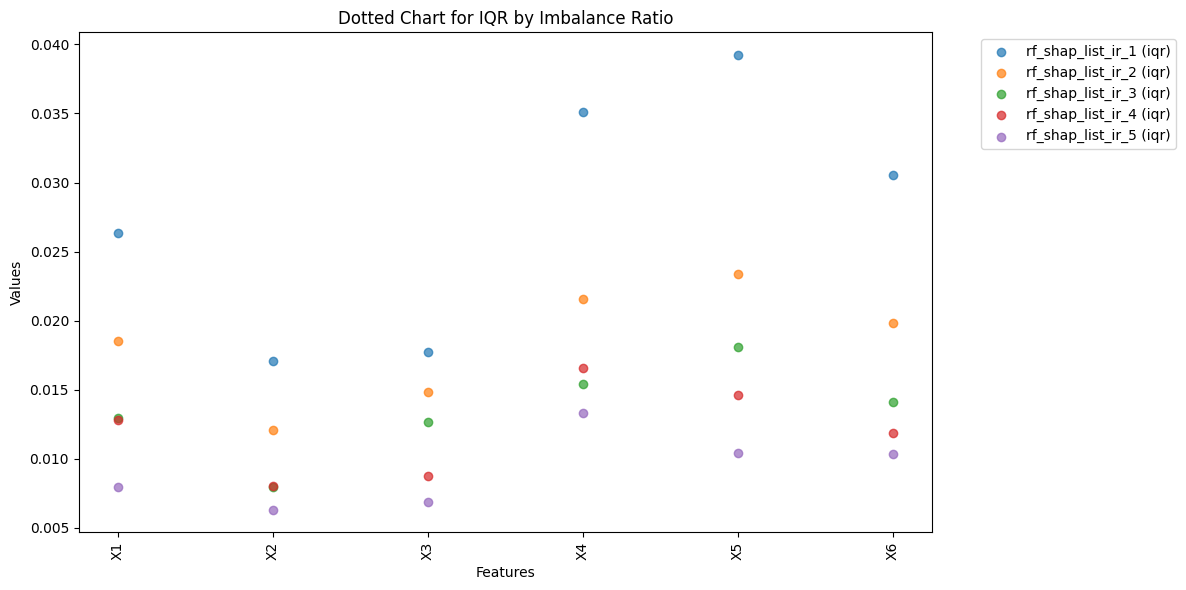

In [27]:
# Reset index to prepare for plotting
df_reset = meanStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
    plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for IQR by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [28]:
#Not Working at all
import pandas as pd
import numpy as np
import itertools
from scipy.special import factorial

# Load the dataset
sorted_orderValuesScore = pd.read_csv("sorted_orderValuesScore_rf.csv")
sorted_orderValuesScore.drop("Unnamed: 0", axis=1, inplace=True)
sorted_orderValuesScore.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

# Get unique features and imbalance ratios
features = sorted_orderValuesScore['feature'].unique()
imbalance_ratios = sorted_orderValuesScore['imbalance_ratio'].unique()

# Function: Westenberg-Mood Test for IQR Equality
def westenberg_mood_test(x, y):
    x, y = np.array(x), np.array(y)
    if len(x) < 2 or len(y) < 2:
        return 1  # If not enough data, assume no difference

    # Center the data by subtracting the median
    x_centered, y_centered = x - np.median(x), y - np.median(y)

    # Compute IQR (25th-75th percentiles) from the combined data
    combined = np.concatenate([x_centered, y_centered])
    q1, q3 = np.percentile(combined, [25, 75])

    # Count values inside and outside the IQR
    a, b = np.sum((q1 < x_centered) & (x_centered < q3)), len(x) - np.sum((q1 < x_centered) & (x_centered < q3))
    c, d = np.sum((q1 < y_centered) & (y_centered < q3)), len(y) - np.sum((q1 < y_centered) & (y_centered < q3))

    # Contingency table
    m = np.array([[a, c], [b, d]])

    # Compute the p-value
    numer = np.sum(np.log(factorial(m.sum(axis=1)))) + np.sum(np.log(factorial(m.sum(axis=0))))
    denom = np.sum(np.log(factorial(m.flatten()))) + np.log(factorial(m.sum()))
    p_value = 2 * np.exp(numer - denom)

    return p_value

# Dictionary to store rankings based on IQR comparison using the Westenberg-Mood test
rankings_iqr_dict = {feature: {} for feature in features}

for feature in features:
    # Filter data for the feature
    feature_data = sorted_orderValuesScore[sorted_orderValuesScore['feature'] == feature]

    # Compute IQR per IR
    iqr_values = feature_data.groupby('imbalance_ratio')['shapMean'].apply(lambda x: x.quantile(0.75) - x.quantile(0.25)).sort_values(ascending=False)
    
    # Initialize significance matrix
    significance_matrix = pd.DataFrame(1.0, index=imbalance_ratios, columns=imbalance_ratios)

    # Apply the Westenberg-Mood test for IQR comparison
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        group1 = feature_data[feature_data['imbalance_ratio'] == ir1]['shapMean']
        group2 = feature_data[feature_data['imbalance_ratio'] == ir2]['shapMean']
        
        if len(group1) > 1 and len(group2) > 1:  # Ensure sufficient data
            p_value = westenberg_mood_test(group1, group2)
        else:
            p_value = 1  # Assume no difference if insufficient data
        
        # Store p-value
        significance_matrix.loc[ir1, ir2] = p_value
        significance_matrix.loc[ir2, ir1] = p_value

    # Assign initial rankings based on IQR values
    ranking_values = {ir: rank + 1 for rank, ir in enumerate(iqr_values.index)}

    # Adjust rankings if no significant differences
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        if significance_matrix.loc[ir1, ir2] >= 0.05:  # No significant difference
            min_rank = min(ranking_values[ir1], ranking_values[ir2])
            ranking_values[ir1] = ranking_values[ir2] = min_rank

    rankings_iqr_dict[feature] = ranking_values

# Convert to DataFrame
ranking_iqr_table = pd.DataFrame(rankings_iqr_dict).T.fillna(0)

# Reorder the columns based on IR numeric values
sorted_columns = sorted(ranking_iqr_table.columns, key=lambda x: int(x.split('_')[-1]))
ranking_iqr_table = ranking_iqr_table[sorted_columns]

# Function to adjust rankings so that ties do not skip numbers
def adjust_rankings(df):
    adjusted_df = df.copy()
    
    for feature in df.index:
        unique_ranks = sorted(set(df.loc[feature]))  # Get unique ranks in sorted order
        rank_mapping = {old_rank: new_rank + 1 for new_rank, old_rank in enumerate(unique_ranks)}  # Map old ranks to new continuous ranks
        
        # Apply mapping to adjust ranks
        adjusted_df.loc[feature] = df.loc[feature].map(rank_mapping)

    return adjusted_df

# Apply the function to adjust rankings
ranking_iqr_table = adjust_rankings(ranking_iqr_table)


# Print the ranking table
tools.display_dataframe_to_user(name="Adjusted Ranking of the IQR by IR for shapMeans", dataframe=ranking_iqr_table)


Adjusted Ranking of the IQR by IR for shapMeans


Loading ITables v2.4.4 from the internet... (need help?)


### Plots shapMeans

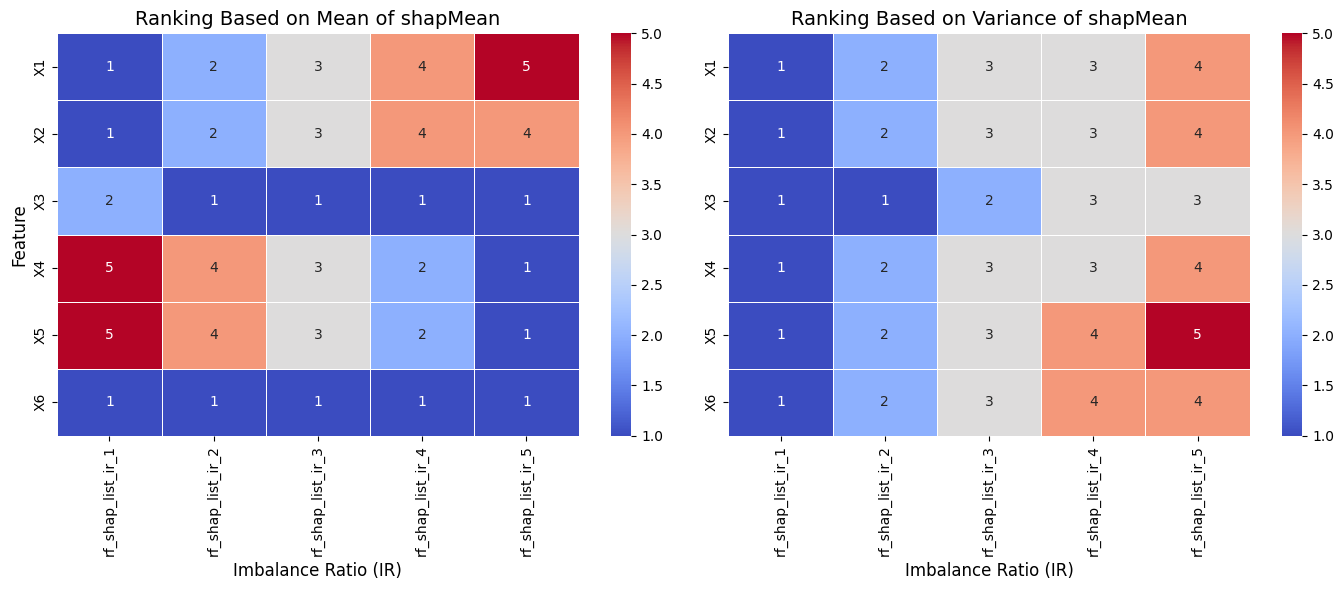

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure for heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap for Mean-based Ranking
sns.heatmap(ranking_table, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".0f", ax=axes[0])
axes[0].set_title("Ranking Based on Mean of shapMean", fontsize=14)
axes[0].set_xlabel("Imbalance Ratio (IR)", fontsize=12)
axes[0].set_ylabel("Feature", fontsize=12)

# Heatmap for Variance-based Ranking
sns.heatmap(ranking_std_table, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".0f", ax=axes[1])
axes[1].set_title("Ranking Based on Variance of shapMean", fontsize=14)
axes[1].set_xlabel("Imbalance Ratio (IR)", fontsize=12)
axes[1].set_ylabel("")  # No label to avoid redundancy

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


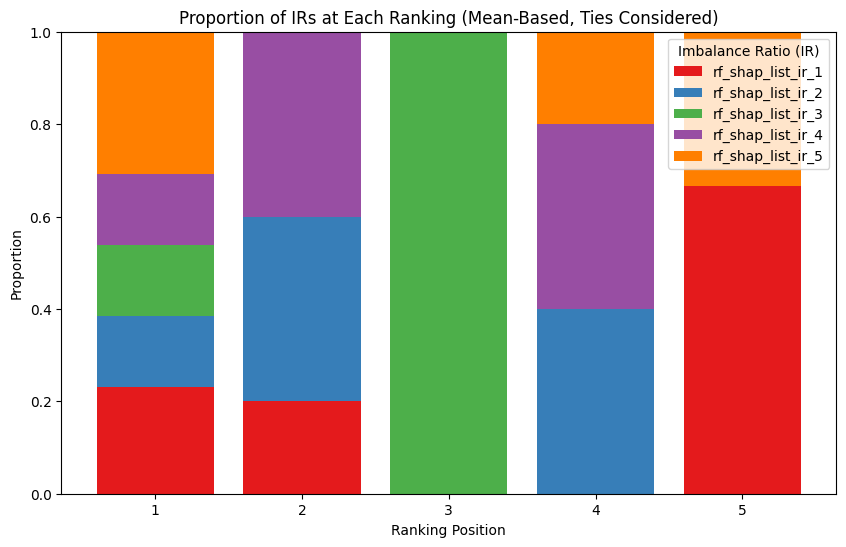

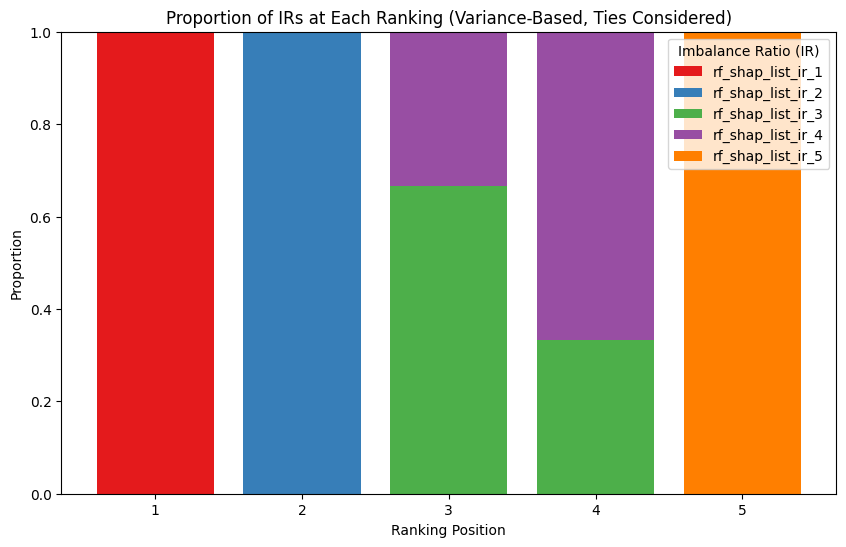

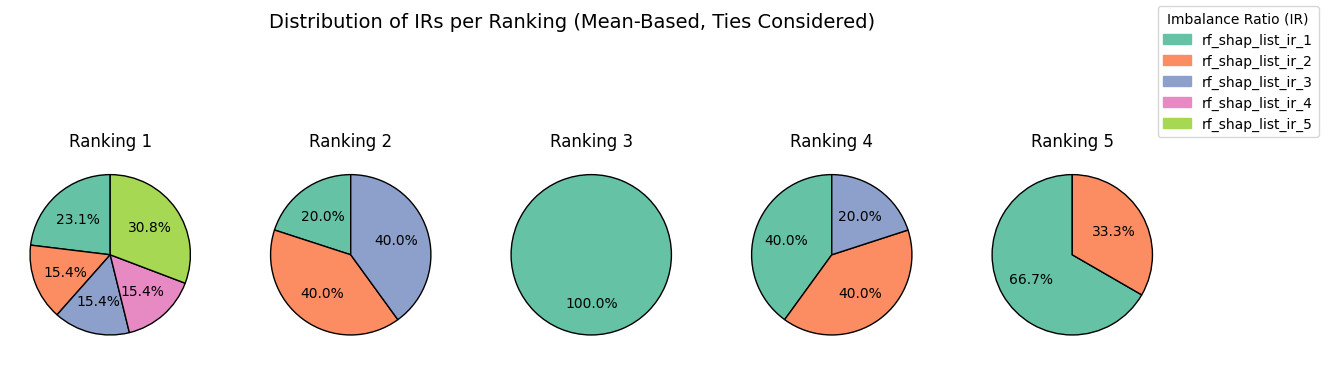

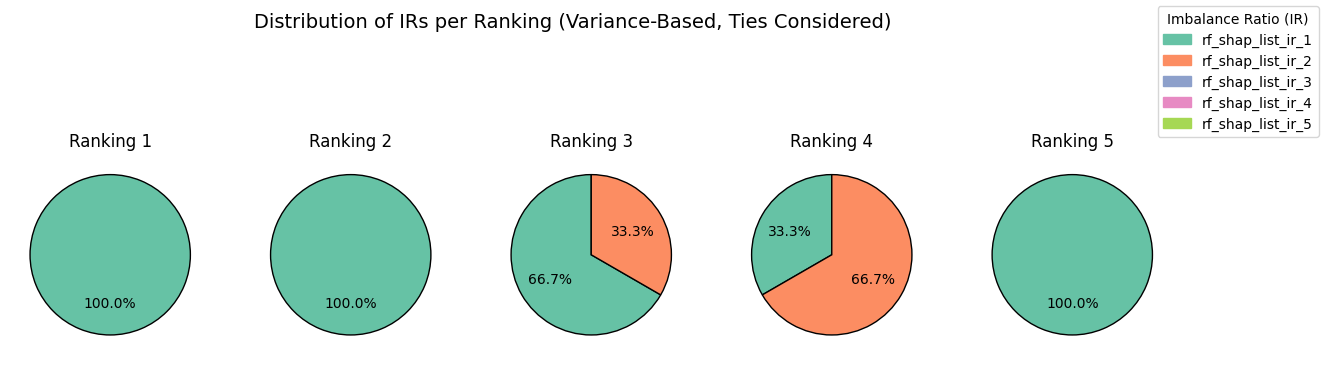

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the ranking tables (assuming they are already defined)
# ranking_table -> Mean-based rankings
# ranking_iqr_table -> Variance-based rankings

# Function to compute ranking proportions, accounting for ties
def compute_ranking_proportions(ranking_df):
    ranking_counts = ranking_df.apply(pd.Series.value_counts, axis=0).fillna(0)
    ranking_proportions = ranking_counts.div(ranking_counts.sum(axis=1), axis=0)
    
    return ranking_proportions

# Function to plot stacked bar chart
def plot_stacked_bar_chart(ranking_df, title):
    ranking_proportions = compute_ranking_proportions(ranking_df)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = sns.color_palette("Set1", len(ranking_df.columns))

    bottom_values = np.zeros(len(ranking_proportions.index))
    for i, ir in enumerate(ranking_df.columns):
        ax.bar(ranking_proportions.index, ranking_proportions[ir], label=ir, bottom=bottom_values, color=colors[i])
        bottom_values += ranking_proportions[ir]

    ax.set_xlabel("Ranking Position")
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    ax.legend(title="Imbalance Ratio (IR)")
    ax.set_ylim(0, 1)

    plt.show()

# Function to plot pie charts for each ranking position (handling ties and removing 0%)
def plot_pie_charts(ranking_df, title):
    ranking_proportions = compute_ranking_proportions(ranking_df)

    fig, axes = plt.subplots(1, len(ranking_proportions.index), figsize=(15, 5))
    colors = sns.color_palette("Set2", len(ranking_df.columns))  # Define consistent colors for IRs

    all_labels = ranking_proportions.columns
    used_labels = set()  # Store IRs that appear in any pie for legend

    for i, rank in enumerate(ranking_proportions.index):
        ax = axes[i]
        proportions = ranking_proportions.loc[rank]

        # Remove IRs with 0% from labels and values
        valid_indices = proportions > 0
        filtered_proportions = proportions[valid_indices]
        filtered_labels = all_labels[valid_indices]

        # Store used IRs for the legend
        used_labels.update(filtered_labels)

        # Plot Pie Chart
        wedges, texts, autotexts = ax.pie(
            filtered_proportions,
            labels=[None] * len(filtered_labels),  # Remove labels inside pie
            autopct=lambda p: f'{p:.1f}%' if p > 0 else '',  # Only show % > 0
            colors=[colors[i] for i in range(len(filtered_labels))],
            startangle=90,
            wedgeprops={'edgecolor': 'black'}
        )

        ax.set_title(f"Ranking {rank}")

    # Create a single legend
    fig.legend(
        handles=[plt.Rectangle((0, 0), 1, 1, color=colors[i]) for i, lbl in enumerate(all_labels) if lbl in used_labels],
        labels=[lbl for lbl in all_labels if lbl in used_labels],
        title="Imbalance Ratio (IR)",
        loc="upper right"
    )

    fig.suptitle(title, fontsize=14)
    plt.show()

# Generate Stacked Bar Chart for Mean-Based Rankings (handling ties)
plot_stacked_bar_chart(ranking_table, "Proportion of IRs at Each Ranking (Mean-Based, Ties Considered)")

# Generate Stacked Bar Chart for Variance-Based Rankings (handling ties)
plot_stacked_bar_chart(ranking_iqr_table, "Proportion of IRs at Each Ranking (Variance-Based, Ties Considered)")

# Generate Pie Charts for Mean-Based Rankings (handling ties)
plot_pie_charts(ranking_table, "Distribution of IRs per Ranking (Mean-Based, Ties Considered)")

# Generate Pie Charts for Variance-Based Rankings (handling ties)
plot_pie_charts(ranking_iqr_table, "Distribution of IRs per Ranking (Variance-Based, Ties Considered)")


***
***
***
## std SHAP

- Variability of std for Shap (level I Shap, for subsets)
- Not only standard deviation increasing with increasing Imbalance Ration, but also Shap std is more changing for highier imbalance. It meas that there is more outlier results for highier IR

In [31]:
# Group by 'imbalanceRatio' and compute statistics for 'shapMean'
stdStatistics = (
    sorted_orderValuesScore.groupby(["imbalance_ratio", 'feature'])
    .agg(
        median=("shapStd", "median"),
        mean=("shapStd", "mean"),
        std=("shapStd", "std"),
        iqr=("shapStd", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )
)
stdStatistics.reset_index(inplace=True)

In [32]:
stdStatistics

,imbalance_ratio,feature,median,mean,std,iqr
0,rf_shap_list_ir_1,X1,0.036862,0.038254,0.012279,0.017331
1,rf_shap_list_ir_1,X2,0.038037,0.040061,0.010011,0.012614
2,rf_shap_list_ir_1,X3,0.045060,0.046190,0.012891,0.017687
3,rf_shap_list_ir_1,X4,0.053314,0.053813,0.008766,0.012006
4,rf_shap_list_ir_1,X5,0.041076,0.040590,0.011124,0.014015
5,rf_shap_list_ir_1,X6,0.037686,0.039034,0.010429,0.013418
6,rf_shap_list_ir_2,X1,0.033341,0.034217,0.009220,0.010254
7,rf_shap_list_ir_2,X2,0.041026,0.040962,0.008188,0.011427
8,rf_shap_list_ir_2,X3,0.044851,0.045691,0.009584,0.013594
9,rf_shap_list_ir_2,X4,0.058774,0.059363,0.006947,0.008404


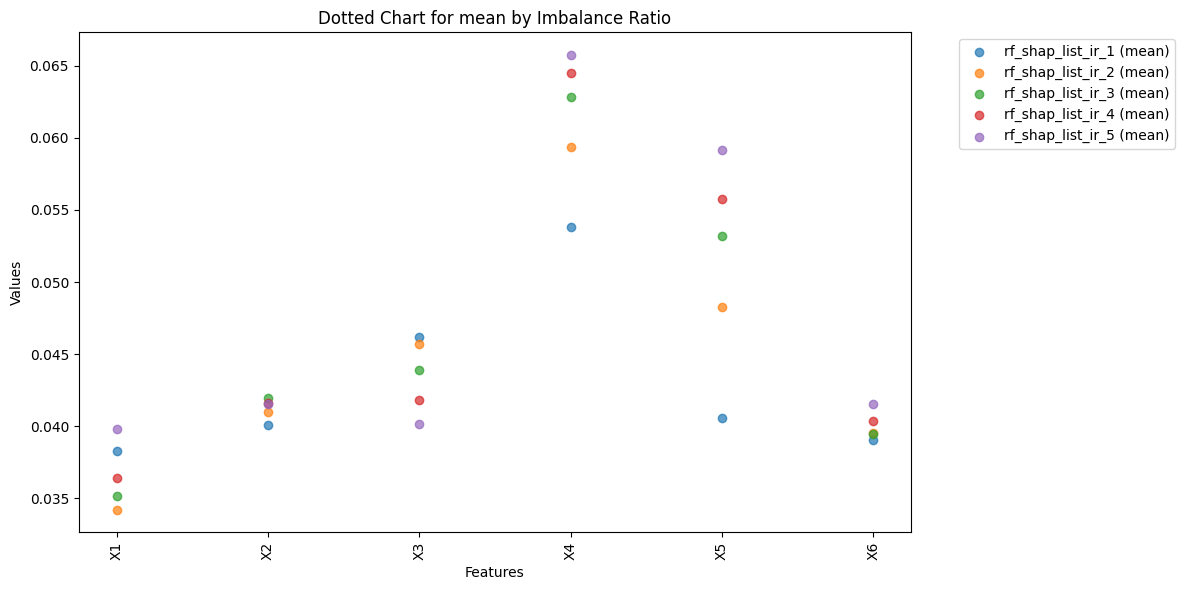

In [33]:
# Reset index to prepare for plotting
df_reset = stdStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)  # median chart
    plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)  # mean chart
#     plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)  # std chart
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)  # iqr chart

plt.xticks(rotation=90)
plt.title("Dotted Chart for mean by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [34]:
import pandas as pd
import scipy.stats as stats
import itertools

# Load your dataset
sorted_orderValuesScore = pd.read_csv("sorted_orderValuesScore_rf.csv")
sorted_orderValuesScore.drop("Unnamed: 0", axis=1, inplace=True)
sorted_orderValuesScore.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

# Get unique IRs and features
imbalance_ratios = sorted_orderValuesScore['imbalance_ratio'].unique()
features = sorted_orderValuesScore['feature'].unique()

# Dictionary to store rankings
rankings_dict = {feature: {} for feature in features}

for feature in features:
    # Filter data for the feature
    feature_data = sorted_orderValuesScore[sorted_orderValuesScore['feature'] == feature]

    # Compute mean shapMean per IR
    means = feature_data.groupby('imbalance_ratio')['shapStd'].mean().sort_values(ascending=False)
    
    # Initialize significance matrix
    significance_matrix = pd.DataFrame(1.0, index=imbalance_ratios, columns=imbalance_ratios)

    # Pairwise t-tests
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        group1 = feature_data[feature_data['imbalance_ratio'] == ir1]['shapMean']
        group2 = feature_data[feature_data['imbalance_ratio'] == ir2]['shapMean']
        
        if len(group1) > 1 and len(group2) > 1:  # Ensure enough data
            stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)  # Welch’s t-test
        else:
            p_value = 1  # Assume no difference if insufficient data
        
        # Store p-value
        significance_matrix.loc[ir1, ir2] = p_value
        significance_matrix.loc[ir2, ir1] = p_value

    # Assign initial rankings based on means
    ranking_values = {ir: rank + 1 for rank, ir in enumerate(means.index)}

    # Adjust rankings if no significant differences
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        if significance_matrix.loc[ir1, ir2] >= 0.05:  # No significant difference
            min_rank = min(ranking_values[ir1], ranking_values[ir2])
            ranking_values[ir1] = ranking_values[ir2] = min_rank

    rankings_dict[feature] = ranking_values

# Convert to DataFrame
ranking_table = pd.DataFrame(rankings_dict).T.fillna(0)

sorted_columns = sorted(ranking_table.columns, key=lambda x: int(x.split('_')[-1]))

# Reorder the DataFrame
ranking_table = ranking_table[sorted_columns]

# Function to adjust rankings so that ties do not skip numbers
def adjust_rankings(df):
    adjusted_df = df.copy()
    
    for feature in df.index:
        unique_ranks = sorted(set(df.loc[feature]))  # Get unique ranks in sorted order
        rank_mapping = {old_rank: new_rank + 1 for new_rank, old_rank in enumerate(unique_ranks)}  # Map old ranks to new continuous ranks
        
        # Apply mapping to adjust ranks
        adjusted_df.loc[feature] = df.loc[feature].map(rank_mapping)

    return adjusted_df

# Apply the function to adjust rankings
ranking_table = adjust_rankings(ranking_table)

# Display the updated ranking table
tools.display_dataframe_to_user(name="Adjusted Ranking of the mean by IR for shapStd", dataframe=ranking_table)


Adjusted Ranking of the mean by IR for shapStd


Loading ITables v2.4.4 from the internet... (need help?)


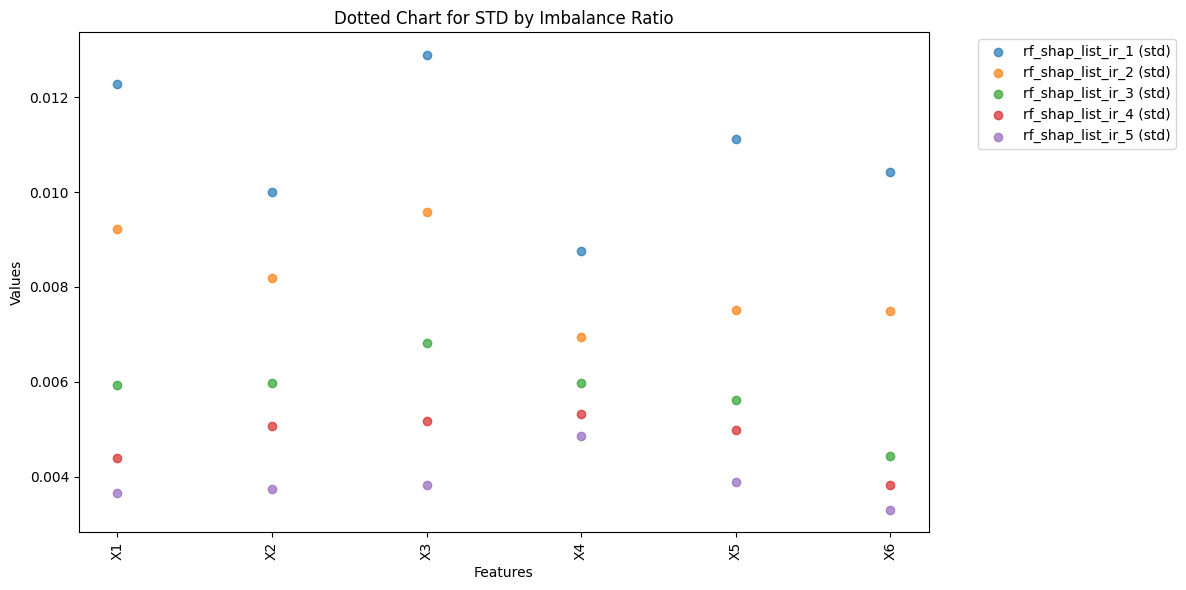

In [35]:
# Reset index to prepare for plotting
df_reset = stdStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
    plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for STD by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [36]:
import pandas as pd
import scipy.stats as stats
import itertools

# Load the dataset
sorted_orderValuesScore = pd.read_csv("sorted_orderValuesScore_rf.csv")
sorted_orderValuesScore.drop("Unnamed: 0", axis=1, inplace=True)
sorted_orderValuesScore.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

# Get unique features and imbalance ratios
features = sorted_orderValuesScore['feature'].unique()
imbalance_ratios = sorted_orderValuesScore['imbalance_ratio'].unique()

# Dictionary to store rankings based on standard deviation of shapMean
rankings_std_dict = {feature: {} for feature in features}

for feature in features:
    # Filter data for the feature
    feature_data = sorted_orderValuesScore[sorted_orderValuesScore['feature'] == feature]

    # Compute std deviation of shapMean per IR
    std_devs = feature_data.groupby('imbalance_ratio')['shapStd'].std().sort_values(ascending=False)
    
    # Initialize significance matrix
    significance_matrix = pd.DataFrame(1.0, index=imbalance_ratios, columns=imbalance_ratios)

    # Pairwise Levene's test for variance comparison
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        group1 = feature_data[feature_data['imbalance_ratio'] == ir1]['shapMean']
        group2 = feature_data[feature_data['imbalance_ratio'] == ir2]['shapMean']
        
        if len(group1) > 1 and len(group2) > 1:  # Ensure enough data
            stat, p_value = stats.levene(group1, group2, center='median')  # Levene’s test
        else:
            p_value = 1  # Assume no difference if insufficient data
        
        # Store p-value
        significance_matrix.loc[ir1, ir2] = p_value
        significance_matrix.loc[ir2, ir1] = p_value

    # Assign initial rankings based on standard deviations
    ranking_values = {ir: rank + 1 for rank, ir in enumerate(std_devs.index)}

    # Adjust rankings if no significant differences
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        if significance_matrix.loc[ir1, ir2] >= 0.05:  # No significant difference
            min_rank = min(ranking_values[ir1], ranking_values[ir2])
            ranking_values[ir1] = ranking_values[ir2] = min_rank

    rankings_std_dict[feature] = ranking_values

# Convert to DataFrame
ranking_std_table = pd.DataFrame(rankings_std_dict).T.fillna(0)

# Reorder the columns based on IR numeric values
sorted_columns = sorted(ranking_std_table.columns, key=lambda x: int(x.split('_')[-1]))
ranking_std_table = ranking_std_table[sorted_columns]

# Function to adjust rankings so that ties do not skip numbers
def adjust_rankings(df):
    adjusted_df = df.copy()
    
    for feature in df.index:
        unique_ranks = sorted(set(df.loc[feature]))  # Get unique ranks in sorted order
        rank_mapping = {old_rank: new_rank + 1 for new_rank, old_rank in enumerate(unique_ranks)}  # Map old ranks to new continuous ranks
        
        # Apply mapping to adjust ranks
        adjusted_df.loc[feature] = df.loc[feature].map(rank_mapping)

    return adjusted_df

# Apply the function to adjust rankings
ranking_std_table = adjust_rankings(ranking_std_table)

# Display the updated ranking table
tools.display_dataframe_to_user(name="Adjusted Ranking of the variance by IR for shapStd", dataframe=ranking_std_table)


Adjusted Ranking of the variance by IR for shapStd


Loading ITables v2.4.4 from the internet... (need help?)


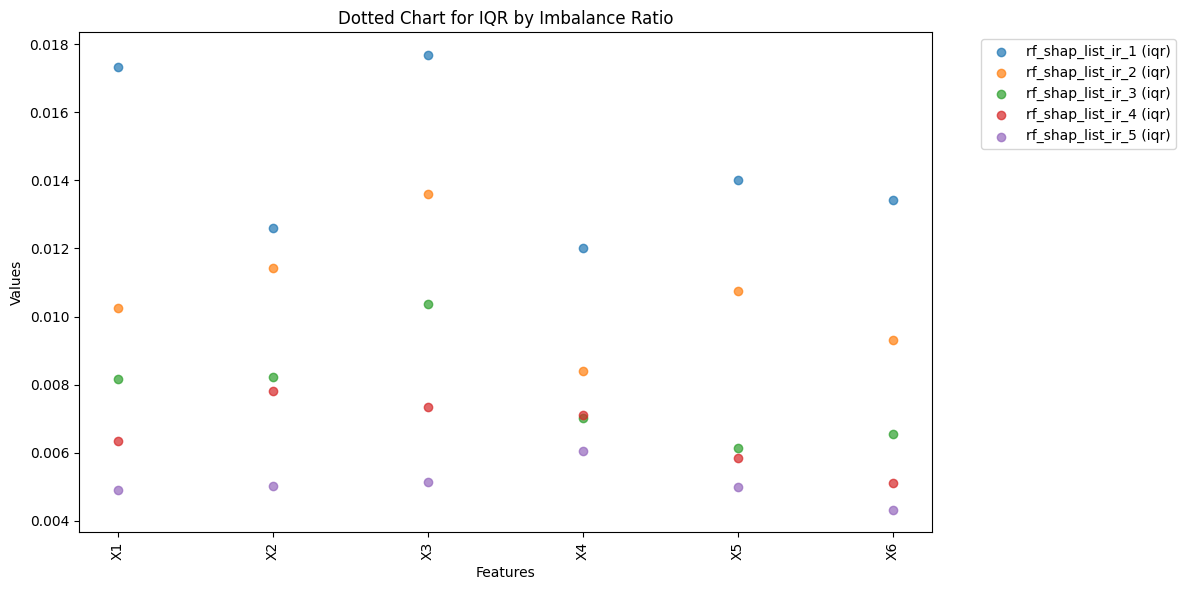

In [37]:
# Reset index to prepare for plotting
df_reset = stdStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
    plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for IQR by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

***
***
***
## SHAP stats by ID

In [38]:
import os
import pandas as pd
import numpy as np
from glob import glob

# Definir la ruta donde se encuentran los archivos SHAP
shap_path = "/home/guillen/Conference Paper SHAP Maciej actualizado/Mammography/shap/"

# Iterar sobre cada IR (1 a 5)
for j in range(1, 6):
    # Lista para almacenar los DataFrames procesados para este IR
    df_list = []

    # Iterar sobre cada subset (1 a 160)
    for i in range(1, 149):
        # Cargar los archivos SHAP para cada clase
        shap_file_0 = os.path.join(shap_path, f"rf_shap_list_ir_{j}_subset_{i}_class0.parquet")
        shap_file_1 = os.path.join(shap_path, f"rf_shap_list_ir_{j}_subset_{i}_class1.parquet")

        if os.path.exists(shap_file_0) and os.path.exists(shap_file_1):
            df_0 = pd.read_parquet(shap_file_0)
            df_1 = pd.read_parquet(shap_file_1)

            # Seleccionar filas de df_0 cuando la clase real es 'NO'
            df_0_filtered = df_0[df_0['Real_class'] == 'NO']

            # Seleccionar filas de df_1 cuando la clase real es 'SI'
            df_1_filtered = df_1[df_1['Real_class'] == 'SI']

            # Concatenar ambos DataFrames
            df_selected = pd.concat([df_0_filtered, df_1_filtered], ignore_index=True)

            # Tomar valores absolutos de los SHAP values
            feature_cols = [col for col in df_selected.columns if col not in ['PATIENT_ID', 'Real_class', 'Predicted_class', 'Model_Output']]
            df_selected[feature_cols] = df_selected[feature_cols].abs()

            df_list.append(df_selected)
        else:
            print(f"Skipping missing files for IR {j}, subset {i}")

    # Verificar que se han cargado datos antes de concatenar
    if df_list:
        # Concatenar todos los datasets de este IR
        df_all = pd.concat(df_list, ignore_index=True)

        # Agrupar por `PATIENT_ID` y calcular la media de los valores absolutos de SHAP
        df_grouped = df_all.groupby(['PATIENT_ID', 'Real_class'])[feature_cols].mean().reset_index()

        # Guardar el resultado en un nuevo archivo
        output_filename = os.path.join(shap_path, f"rf_shap_aggregated_ir_{j}.parquet")
        df_grouped.to_parquet(output_filename, index=False)

        print(f"Processed IR {j}: Saved to {output_filename}")
    else:
        print(f"No data found for IR {j}, skipping.")

print("Processing completed! SHAP values have been aggregated and saved.")

Processed IR 1: Saved to /home/guillen/Conference Paper SHAP Maciej actualizado/Mammography/shap/rf_shap_aggregated_ir_1.parquet
Processed IR 2: Saved to /home/guillen/Conference Paper SHAP Maciej actualizado/Mammography/shap/rf_shap_aggregated_ir_2.parquet
Processed IR 3: Saved to /home/guillen/Conference Paper SHAP Maciej actualizado/Mammography/shap/rf_shap_aggregated_ir_3.parquet
Processed IR 4: Saved to /home/guillen/Conference Paper SHAP Maciej actualizado/Mammography/shap/rf_shap_aggregated_ir_4.parquet
Processed IR 5: Saved to /home/guillen/Conference Paper SHAP Maciej actualizado/Mammography/shap/rf_shap_aggregated_ir_5.parquet
Processing completed! SHAP values have been aggregated and saved.


In [39]:
import os
import numpy as np
import pandas as pd
from scipy.stats import iqr
shap_aggregated = {}
for j in range(1, 6):
    shap_path = "/home/guillen/Conference Paper SHAP Maciej actualizado/Mammography/shap/"
    file_path = os.path.join(shap_path, f"rf_shap_aggregated_ir_{j}.parquet")
    shap_aggregated[j] = pd.read_parquet(file_path)

shap_aggregated[1]

,PATIENT_ID,Real_class,X1,X2,X3,X4,X5,X6
0,1,NO,0.043837,0.106457,0.027734,0.124257,0.092395,0.105885
1,2,NO,0.051229,0.033106,0.104532,0.130906,0.086077,0.084601
2,3,NO,0.096060,0.062366,0.085220,0.100554,0.067193,0.081193
3,4,NO,0.036588,0.062985,0.011826,0.187541,0.079221,0.119368
4,5,NO,0.100834,0.032476,0.048297,0.090544,0.143755,0.079591
...,...,...,...,...,...,...,...,...
11178,11179,SI,0.104804,0.010441,0.016427,0.080766,0.200160,0.031601
11179,11180,SI,0.015493,0.028190,0.019113,0.049618,0.175008,0.106182
11180,11181,SI,0.027422,0.093126,0.036573,0.130210,0.178561,0.044530
11181,11182,SI,0.034577,0.013144,0.045189,0.133329,0.043988,0.113982


In [40]:
feature_cols = [col for col in shap_aggregated[1].columns if col not in ['PATIENT_ID', 'Real_class']]

metrics = []
for feature in feature_cols:
    for j in range(1, 6):
        data = shap_aggregated[j][feature]
        metrics.append({
            'feature': feature,
            'IR': j,
            'mean': np.mean(data),
            'median': np.median(data),# Additional metric for ranking
            'std': np.std(data),
            'iqr': iqr(data)
        })

metrics_df = pd.DataFrame(metrics)

# Generate rankings (higher value = rank 1)
ranking_df = metrics_df.copy()
for metric in ['mean', 'std', 'iqr', 'median']:
    ranking_df[metric + '_Rank'] = ranking_df.groupby('feature')[metric].rank(method='dense', ascending=False)

# Display ranking table
import ace_tools_open as tools
tools.display_dataframe_to_user(name="Ranking Metrics by IR", dataframe=ranking_df)

Ranking Metrics by IR


Loading ITables v2.4.4 from the internet... (need help?)


In [41]:
import pandas as pd
import os
import scipy.stats as stats
import itertools

# Define the base path for SHAP files
shap_path = "/home/guillen/Conference Paper SHAP Maciej actualizado/Mammography/shap/"

# Load and combine the SHAP datasets into a single DataFrame
shap_aggregated = []
for j in range(1, 6):
    file_path = os.path.join(shap_path, f"rf_shap_aggregated_ir_{j}.parquet")
    df = pd.read_parquet(file_path)
    df["imbalance_ratio"] = j  # Add new column to track IR
    shap_aggregated.append(df)

# Concatenate all DataFrames into one
combined_shap_df = pd.concat(shap_aggregated, ignore_index=True)

import pandas as pd
import scipy.stats as stats
import itertools

# Select only the relevant columns for analysis
selected_columns = ['X1','X2','X3','X4','X5','X6', 'imbalance_ratio']

# Keep only the selected columns
combined_shap_df = combined_shap_df[selected_columns]

# Get unique IRs and features
imbalance_ratios = sorted(combined_shap_df['imbalance_ratio'].unique())
features = [col for col in selected_columns if col != 'imbalance_ratio']

# Dictionary to store rankings
rankings_dict = {feature: {} for feature in features}

for feature in features:
    # Compute mean value per IR
    means = combined_shap_df.groupby('imbalance_ratio')[feature].mean().sort_values(ascending=False)

    # Initialize significance matrix
    significance_matrix = pd.DataFrame(1.0, index=imbalance_ratios, columns=imbalance_ratios)

    # Pairwise t-tests
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        group1 = combined_shap_df[combined_shap_df['imbalance_ratio'] == ir1][feature]
        group2 = combined_shap_df[combined_shap_df['imbalance_ratio'] == ir2][feature]

        if len(group1) > 1 and len(group2) > 1:  # Ensure enough data
            stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)  # Welch’s t-test
        else:
            p_value = 1  # Assume no difference if insufficient data

        # Store p-value
        significance_matrix.loc[ir1, ir2] = p_value
        significance_matrix.loc[ir2, ir1] = p_value

    # Assign initial rankings based on means
    ranking_values = {ir: rank + 1 for rank, ir in enumerate(means.index)}

    # Adjust rankings if no significant differences
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        if significance_matrix.loc[ir1, ir2] >= 0.05:  # No significant difference
            min_rank = min(ranking_values[ir1], ranking_values[ir2])
            ranking_values[ir1] = ranking_values[ir2] = min_rank

    rankings_dict[feature] = ranking_values

# Convert to DataFrame
ranking_table = pd.DataFrame(rankings_dict).T.fillna(0)

# Reorder the DataFrame based on IR numeric values
sorted_columns = sorted(ranking_table.columns, key=lambda x: int(x))
ranking_table = ranking_table[sorted_columns]

# Function to adjust rankings so that ties do not skip numbers
def adjust_rankings(df):
    adjusted_df = df.copy()
    
    for feature in df.index:
        unique_ranks = sorted(set(df.loc[feature]))  # Get unique ranks in sorted order
        rank_mapping = {old_rank: new_rank + 1 for new_rank, old_rank in enumerate(unique_ranks)}  # Map old ranks to new continuous ranks
        
        # Apply mapping to adjust ranks
        adjusted_df.loc[feature] = df.loc[feature].map(rank_mapping)

    return adjusted_df

# Apply the function to adjust rankings
ranking_table = adjust_rankings(ranking_table)

# Save the ranking table locally
ranking_table.to_csv("ranking_medical_features_rf.csv", index=True)

# Display the ranking table
import ace_tools_open as tools
tools.display_dataframe_to_user(name="Adjusted Ranking of the mean by IR for Medical Features", dataframe=ranking_table)


Adjusted Ranking of the mean by IR for Medical Features


Loading ITables v2.4.4 from the internet... (need help?)


In [42]:
import pandas as pd
import scipy.stats as stats
import itertools

# Select only the relevant medical features and imbalance ratio
selected_columns = ['X1','X2','X3','X4','X5','X6', 'imbalance_ratio']

# Keep only the selected columns
combined_shap_df = combined_shap_df[selected_columns]

# Get unique IRs and features
imbalance_ratios = sorted(combined_shap_df['imbalance_ratio'].unique())
features = [col for col in selected_columns if col != 'imbalance_ratio']

# Dictionary to store rankings based on standard deviation
rankings_std_dict = {feature: {} for feature in features}

for feature in features:
    # Compute standard deviation per IR
    std_devs = combined_shap_df.groupby('imbalance_ratio')[feature].std().sort_values(ascending=False)

    # Initialize significance matrix
    significance_matrix = pd.DataFrame(1.0, index=imbalance_ratios, columns=imbalance_ratios)

    # Pairwise Levene's test for variance comparison
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        group1 = combined_shap_df[combined_shap_df['imbalance_ratio'] == ir1][feature]
        group2 = combined_shap_df[combined_shap_df['imbalance_ratio'] == ir2][feature]

        if len(group1) > 1 and len(group2) > 1:  # Ensure enough data
            stat, p_value = stats.levene(group1, group2, center='median')  # Levene’s test for variance
        else:
            p_value = 1  # Assume no difference if insufficient data

        # Store p-value
        significance_matrix.loc[ir1, ir2] = p_value
        significance_matrix.loc[ir2, ir1] = p_value

    # Assign initial rankings based on standard deviations
    ranking_values = {ir: rank + 1 for rank, ir in enumerate(std_devs.index)}

    # Adjust rankings if no significant differences
    for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
        if significance_matrix.loc[ir1, ir2] >= 0.05:  # No significant difference
            min_rank = min(ranking_values[ir1], ranking_values[ir2])
            ranking_values[ir1] = ranking_values[ir2] = min_rank

    rankings_std_dict[feature] = ranking_values

# Convert to DataFrame
ranking_std_table = pd.DataFrame(rankings_std_dict).T.fillna(0)

# Reorder the DataFrame based on IR numeric values
sorted_columns = sorted(ranking_std_table.columns, key=lambda x: int(x))
ranking_std_table = ranking_std_table[sorted_columns]

# Function to adjust rankings so that ties do not skip numbers
def adjust_rankings(df):
    adjusted_df = df.copy()
    
    for feature in df.index:
        unique_ranks = sorted(set(df.loc[feature]))  # Get unique ranks in sorted order
        rank_mapping = {old_rank: new_rank + 1 for new_rank, old_rank in enumerate(unique_ranks)}  # Map old ranks to new continuous ranks
        
        # Apply mapping to adjust ranks
        adjusted_df.loc[feature] = df.loc[feature].map(rank_mapping)

    return adjusted_df

# Apply the function to adjust rankings
ranking_std_table = adjust_rankings(ranking_std_table)

# Save the ranking table locally
ranking_std_table.to_csv("ranking_variance_medical_features_rf.csv", index=True)

# Display the updated ranking table
import ace_tools_open as tools
tools.display_dataframe_to_user(name="Adjusted Ranking of the variance by IR for Medical Features", dataframe=ranking_std_table)


Adjusted Ranking of the variance by IR for Medical Features


Loading ITables v2.4.4 from the internet... (need help?)


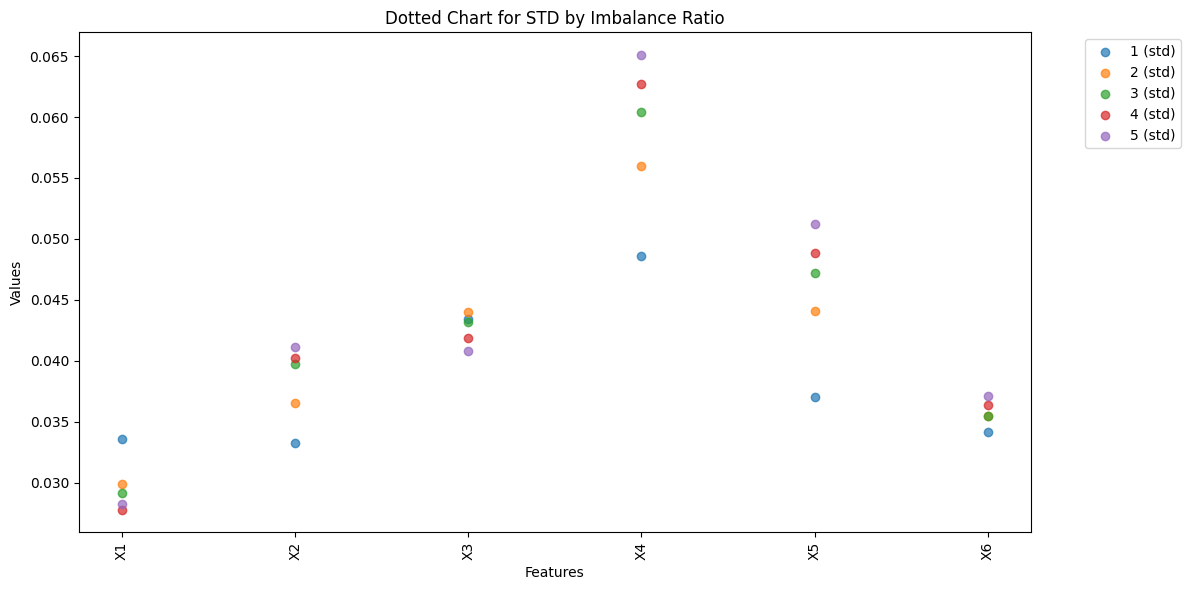

In [43]:
plt.figure(figsize=(12, 6))
for ir in ranking_df["IR"].unique():
    subset = ranking_df[ranking_df["IR"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
    plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for STD by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

***
***
***
## Features ranking based on position/order/significance

In [44]:
sorted_orderScore[:3]

,imbalanceRatio,Subset,Indicator,Sorted_Features
0,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,orderMean,"['X4', 'X5', 'X6', 'X2', 'X1', 'X3']"
1,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,orderStd,"['X4', 'X6', 'X5', 'X3', 'X2', 'X1']"
2,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,orderSum,"['X4', 'X5', 'X6', 'X2', 'X1', 'X3']"


In [45]:
sorted_orderScore[sorted_orderScore['Indicator']=='orderMean'][['imbalanceRatio', 'Subset', 'Indicator', 'Sorted_Features']]

,imbalanceRatio,Subset,Indicator,Sorted_Features
0,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,orderMean,"['X4', 'X5', 'X6', 'X2', 'X1', 'X3']"
3,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_88,orderMean,"['X4', 'X5', 'X6', 'X3', 'X1', 'X2']"
6,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_94,orderMean,"['X5', 'X4', 'X6', 'X1', 'X2', 'X3']"
9,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_129,orderMean,"['X4', 'X6', 'X1', 'X2', 'X3', 'X5']"
12,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_68,orderMean,"['X4', 'X5', 'X6', 'X3', 'X1', 'X2']"
...,...,...,...,...
2205,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_12,orderMean,"['X4', 'X5', 'X6', 'X1', 'X3', 'X2']"
2208,rf_shap_list_ir_5,rf_shap_list_ir_5_subset_123,orderMean,"['X4', 'X5', 'X6', 'X3', 'X1', 'X2']"
2211,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_62,orderMean,"['X4', 'X6', 'X5', 'X1', 'X2', 'X3']"
2214,rf_shap_list_ir_2,rf_shap_list_ir_2_subset_7,orderMean,"['X4', 'X5', 'X1', 'X2', 'X6', 'X3']"


In [46]:
import pandas as pd

def extract_top_features(dataframe, column_name, top_features_amount):
    """
    Extract the top X features from the specified column in the DataFrame and add them as a new column.

    Parameters:
        dataframe (pd.DataFrame): Input DataFrame.
        column_name (str): Name of the column containing feature lists as strings.
        top_features_amount (int): Number of top features to extract.

    Returns:
        pd.DataFrame: DataFrame with an additional column containing the top X features as lists.
    """
    dataframe[f'top_{top_features_amount}_features'] = dataframe[column_name].apply(
        lambda x: eval(x)[:top_features_amount]
    )
    return dataframe





In [47]:
# use of extract_top_features 
df = sorted_orderScore[sorted_orderScore['Indicator']=='orderMean'][['imbalanceRatio', 'Subset', 'Indicator', 'Sorted_Features']].copy()

# Define the number of top features to extract
top_features_amount = 5

# Apply the function to extract top features
orderIndicator = extract_top_features(df, "Sorted_Features", top_features_amount)

In [48]:
def calculate_unique_feature_lists_per_group(dataframe, group_column, list_column):
    """
    Calculate unique lists in the specified column of the DataFrame for each group.

    Parameters:
        dataframe (pd.DataFrame): Input DataFrame.
        group_column (str): Name of the column to group by.
        list_column (str): Name of the column containing feature lists as strings or lists.

    Returns:
        pd.DataFrame: DataFrame with columns for group values and unique feature lists.
    """
    unique_lists_per_group = []

    # Group by the specified column
    for group, group_df in dataframe.groupby(group_column):
        # Convert each list in the column to a tuple (to account for order sensitivity) and collect unique tuples
        unique_lists = set(tuple(row) for row in group_df[list_column].apply(lambda x: eval(x) if isinstance(x, str) else x))
        for unique_list in unique_lists:
            unique_lists_per_group.append({group_column: group, "unique_feature_list": unique_list})

    return pd.DataFrame(unique_lists_per_group)

In [49]:
orderIndicator

,imbalanceRatio,Subset,Indicator,Sorted_Features,top_5_features
0,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_35,orderMean,"['X4', 'X5', 'X6', 'X2', 'X1', 'X3']","[X4, X5, X6, X2, X1]"
3,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_88,orderMean,"['X4', 'X5', 'X6', 'X3', 'X1', 'X2']","[X4, X5, X6, X3, X1]"
6,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_94,orderMean,"['X5', 'X4', 'X6', 'X1', 'X2', 'X3']","[X5, X4, X6, X1, X2]"
9,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_129,orderMean,"['X4', 'X6', 'X1', 'X2', 'X3', 'X5']","[X4, X6, X1, X2, X3]"
12,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_68,orderMean,"['X4', 'X5', 'X6', 'X3', 'X1', 'X2']","[X4, X5, X6, X3, X1]"
...,...,...,...,...,...
2205,rf_shap_list_ir_3,rf_shap_list_ir_3_subset_12,orderMean,"['X4', 'X5', 'X6', 'X1', 'X3', 'X2']","[X4, X5, X6, X1, X3]"
2208,rf_shap_list_ir_5,rf_shap_list_ir_5_subset_123,orderMean,"['X4', 'X5', 'X6', 'X3', 'X1', 'X2']","[X4, X5, X6, X3, X1]"
2211,rf_shap_list_ir_1,rf_shap_list_ir_1_subset_62,orderMean,"['X4', 'X6', 'X5', 'X1', 'X2', 'X3']","[X4, X6, X5, X1, X2]"
2214,rf_shap_list_ir_2,rf_shap_list_ir_2_subset_7,orderMean,"['X4', 'X5', 'X1', 'X2', 'X6', 'X3']","[X4, X5, X1, X2, X6]"


In [50]:
df = orderIndicator.copy()

# Calculate unique feature lists for each imbalanceRatio
unique_feature_lists_df = calculate_unique_feature_lists_per_group(df, "imbalanceRatio", "top_5_features")

In [51]:
unique_feature_lists_df

,imbalanceRatio,unique_feature_list
0,rf_shap_list_ir_1,"(X4, X6, X3, X1, X5)"
1,rf_shap_list_ir_1,"(X6, X4, X5, X2, X1)"
2,rf_shap_list_ir_1,"(X4, X6, X2, X3, X1)"
3,rf_shap_list_ir_1,"(X4, X1, X5, X3, X2)"
4,rf_shap_list_ir_1,"(X4, X6, X2, X5, X1)"
...,...,...
137,rf_shap_list_ir_5,"(X4, X5, X6, X1, X2)"
138,rf_shap_list_ir_5,"(X4, X5, X6, X3, X2)"
139,rf_shap_list_ir_5,"(X4, X5, X6, X3, X1)"
140,rf_shap_list_ir_5,"(X4, X6, X5, X1, X3)"


In [52]:
def add_presence_columns(unique_feature_lists_df, dataframe, group_column, list_column):
    """
    Add new columns to the unique_feature_lists_df for each unique value in the group column.
    Each column indicates the presence (1) or absence (0) of the unique feature list in the original DataFrame's groups.

    Parameters:
        unique_feature_lists_df (pd.DataFrame): DataFrame with unique feature lists.
        dataframe (pd.DataFrame): Original DataFrame.
        group_column (str): Name of the column to group by.
        list_column (str): Name of the column containing feature lists as strings or lists.

    Returns:
        pd.DataFrame: Updated unique_feature_lists_df with new columns.
    """
    group_values = dataframe[group_column].unique()

    for group in group_values:
        group_features = set(
            tuple(row) for row in dataframe[dataframe[group_column] == group][list_column].apply(lambda x: eval(x) if isinstance(x, str) else x)
        )

        unique_feature_lists_df[group] = unique_feature_lists_df["unique_feature_list"].apply(
            lambda x: 1 if x in group_features else 0
        )

    return unique_feature_lists_df

In [53]:
unique_feature_lists_df

,imbalanceRatio,unique_feature_list
0,rf_shap_list_ir_1,"(X4, X6, X3, X1, X5)"
1,rf_shap_list_ir_1,"(X6, X4, X5, X2, X1)"
2,rf_shap_list_ir_1,"(X4, X6, X2, X3, X1)"
3,rf_shap_list_ir_1,"(X4, X1, X5, X3, X2)"
4,rf_shap_list_ir_1,"(X4, X6, X2, X5, X1)"
...,...,...
137,rf_shap_list_ir_5,"(X4, X5, X6, X1, X2)"
138,rf_shap_list_ir_5,"(X4, X5, X6, X3, X2)"
139,rf_shap_list_ir_5,"(X4, X5, X6, X3, X1)"
140,rf_shap_list_ir_5,"(X4, X6, X5, X1, X3)"


In [54]:
unique_feature_lists_df = add_presence_columns(unique_feature_lists_df, unique_feature_lists_df, "imbalanceRatio", "unique_feature_list")

In [55]:
imbalanceRatio_columns = list(unique_feature_lists_df['imbalanceRatio'].unique())

In [56]:
imbalanceRatio_columns

['rf_shap_list_ir_1',
 'rf_shap_list_ir_2',
 'rf_shap_list_ir_3',
 'rf_shap_list_ir_4',
 'rf_shap_list_ir_5']

In [57]:
def add_sum_column(unique_feature_lists_df, imbalanceRatio_columns):
    """
    Add a new column 'sum' to the DataFrame which sums values across specified imbalanceRatio columns.

    Parameters:
        unique_feature_lists_df (pd.DataFrame): DataFrame with unique feature lists and imbalanceRatio columns.
        imbalanceRatio_columns (list): List of column names to sum across.

    Returns:
        pd.DataFrame: Updated unique_feature_lists_df with the 'sum' column.
    """
    unique_feature_lists_df['sum'] = unique_feature_lists_df[imbalanceRatio_columns].sum(axis=1)
    return unique_feature_lists_df

In [58]:
unique_feature_lists_df = add_sum_column(unique_feature_lists_df, imbalanceRatio_columns)

In [59]:
unique_feature_lists_df

,imbalanceRatio,unique_feature_list,rf_shap_list_ir_1,rf_shap_list_ir_2,rf_shap_list_ir_3,rf_shap_list_ir_4,rf_shap_list_ir_5,sum
0,rf_shap_list_ir_1,"(X4, X6, X3, X1, X5)",1,1,0,0,0,2
1,rf_shap_list_ir_1,"(X6, X4, X5, X2, X1)",1,0,0,0,0,1
2,rf_shap_list_ir_1,"(X4, X6, X2, X3, X1)",1,0,0,0,0,1
3,rf_shap_list_ir_1,"(X4, X1, X5, X3, X2)",1,0,0,0,0,1
4,rf_shap_list_ir_1,"(X4, X6, X2, X5, X1)",1,1,0,0,0,2
...,...,...,...,...,...,...,...,...
137,rf_shap_list_ir_5,"(X4, X5, X6, X1, X2)",1,1,1,1,1,5
138,rf_shap_list_ir_5,"(X4, X5, X6, X3, X2)",1,1,1,1,1,5
139,rf_shap_list_ir_5,"(X4, X5, X6, X3, X1)",1,1,1,1,1,5
140,rf_shap_list_ir_5,"(X4, X6, X5, X1, X3)",1,1,1,1,1,5


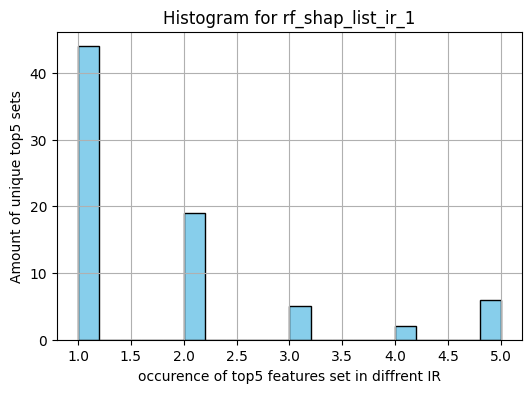

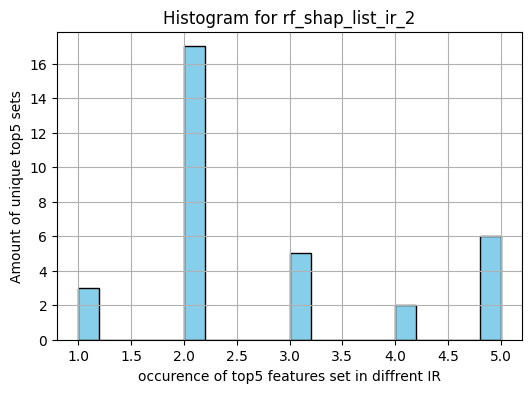

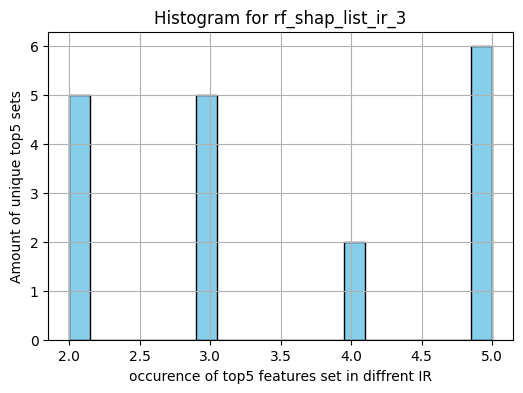

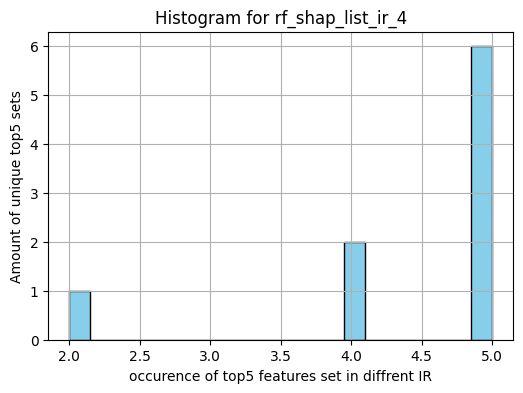

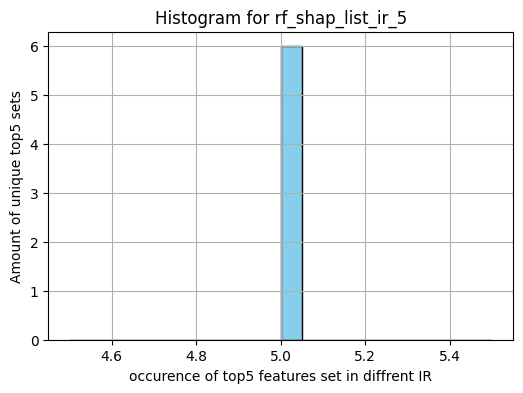

CPU times: user 1.64 s, sys: 48.3 ms, total: 1.69 s
Wall time: 14.8 s


In [60]:
%%time

# Create histograms for each IR, to evaluate how many unique sets of the most important features was made
for ir_name in imbalanceRatio_columns:
    plt.figure(figsize=(6, 4))  # Set figure size
    plt.hist(unique_feature_lists_df[unique_feature_lists_df['imbalanceRatio']==ir_name]['sum'], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram for {ir_name}')
    plt.xlabel('occurence of top5 features set in diffrent IR')
    plt.ylabel('Amount of unique top5 sets')
    plt.grid(True)
    plt.show()

    
    # Save the histogram as a PNG file in the specified folder
#     filename = os.path.join(output_folder, f"Histogram_for_{feature.replace(' ', '_')}.png")  # Replace spaces with underscores for filenames
#     plt.savefig(filename, dpi=300, bbox_inches='tight')

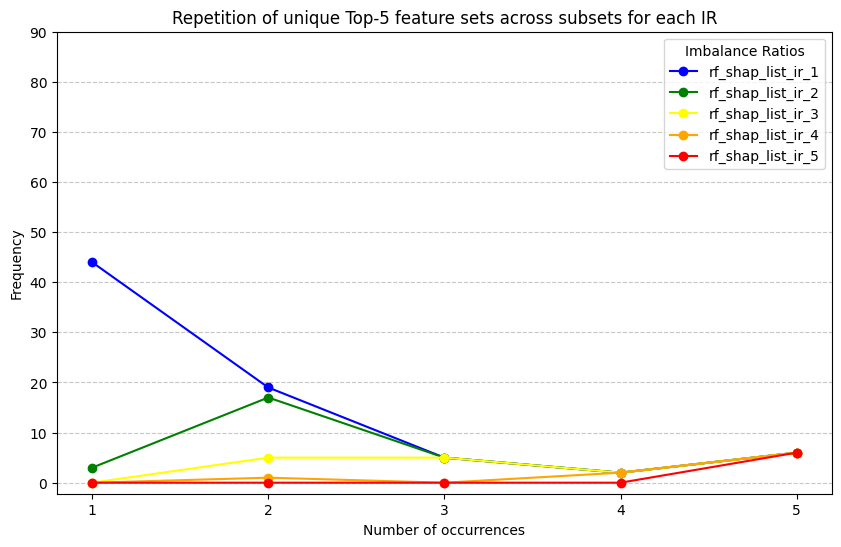

In [61]:
import matplotlib.pyplot as plt
import numpy as np

rank_colors = {1: 'blue', 2: 'green', 3: 'yellow', 4: 'orange', 5: 'red'}
ir_names = unique_feature_lists_df['imbalanceRatio'].unique()
x_values = np.arange(1, 6) 
plt.figure(figsize=(10, 6))

for ir_idx, ir_name in enumerate(ir_names):
    
    rank_counts = [np.sum(unique_feature_lists_df[unique_feature_lists_df['imbalanceRatio'] == ir_name]['sum'] == x) for x in x_values]
    plt.plot(x_values, rank_counts, marker='o', linestyle='-', color=rank_colors.get(ir_idx + 1, 'gray'), label=ir_name)

plt.xlabel('Number of occurrences')
plt.ylabel('Frequency')
plt.title('Repetition of unique Top-5 feature sets across subsets for each IR')
plt.xticks(x_values) 
plt.yticks(np.arange(0, 81 + 10, 10))

plt.legend(title="Imbalance Ratios", loc="upper right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


- Results shows that growing imbalance IR5 => IR1 is shown in different sets of the most significant features.
    - For IR1 models have 40 new, unique sets of the most important features;
    - for IR3 (and less) there is no unique sets for that imbalance ratio 
- there is a trend of less amount of different sets of the most important features, only 8 for IR5, and 

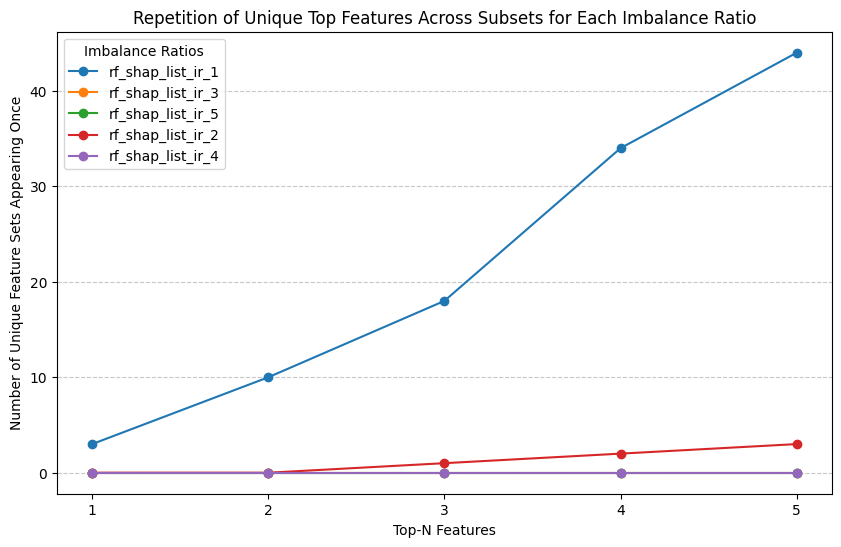

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
file_path = "shap_orderScore_rf.csv"
df = pd.read_csv(file_path)

# Filter only rows where Indicator is 'orderMean'
filtered_df = df[df['Indicator'] == 'orderMean'][['imbalanceRatio', 'Subset', 'Sorted_Features']].copy()

# Function to extract top N features from the Sorted_Features column
def extract_top_features(dataframe, column_name, top_features_amount):
    dataframe[f'top_{top_features_amount}_features'] = dataframe[column_name].apply(
        lambda x: eval(x)[:top_features_amount] if isinstance(x, str) else x[:top_features_amount]
    )
    return dataframe

# Apply the function for top 1 to 5 features
for top_n in range(1, 6):
    filtered_df = extract_top_features(filtered_df, "Sorted_Features", top_n)

# Function to calculate unique feature lists per group
def calculate_unique_feature_lists_per_group(dataframe, group_column, list_column):
    unique_lists_per_group = []
    
    for group, group_df in dataframe.groupby(group_column):
        unique_lists = set(tuple(row) for row in group_df[list_column])
        for unique_list in unique_lists:
            unique_lists_per_group.append({group_column: group, "unique_feature_list": unique_list})
    
    return pd.DataFrame(unique_lists_per_group)

# Process unique feature lists for different top feature amounts
unique_feature_lists = {}
for top_n in range(1, 6):
    unique_feature_lists[top_n] = calculate_unique_feature_lists_per_group(
        filtered_df, "imbalanceRatio", f"top_{top_n}_features"
    )

# Function to add presence columns per imbalance ratio
def add_presence_columns(unique_feature_lists_df, dataframe, group_column, list_column):
    group_values = dataframe[group_column].unique()

    for group in group_values:
        group_features = set(tuple(row) for row in dataframe[dataframe[group_column] == group][list_column])
        unique_feature_lists_df[group] = unique_feature_lists_df["unique_feature_list"].apply(
            lambda x: 1 if x in group_features else 0
        )

    return unique_feature_lists_df

# Add presence columns for each unique feature list dataframe
for top_n in range(1, 6):
    unique_feature_lists[top_n] = add_presence_columns(
        unique_feature_lists[top_n], filtered_df, "imbalanceRatio", f"top_{top_n}_features"
    )

# Summarize occurrences
for top_n in range(1, 6):
    imbalanceRatio_columns = list(unique_feature_lists[top_n]['imbalanceRatio'].unique())
    unique_feature_lists[top_n]['sum'] = unique_feature_lists[top_n][imbalanceRatio_columns].sum(axis=1)

# Generate line plot for unique feature sets appearing exactly once
plt.figure(figsize=(10, 6))
x_values = np.arange(1, 6)  # 1 to 5 features

for ir_name in filtered_df['imbalanceRatio'].unique():
    rank_counts = [
        np.sum(unique_feature_lists[top_n][unique_feature_lists[top_n]['imbalanceRatio'] == ir_name]['sum'] == 1)
        for top_n in range(1, 6)
    ]
    plt.plot(x_values, rank_counts, marker='o', linestyle='-', label=ir_name)

plt.xlabel('Top-N Features')
plt.ylabel('Number of Unique Feature Sets Appearing Once')
plt.title('Repetition of Unique Top Features Across Subsets for Each Imbalance Ratio')
plt.xticks(x_values)
plt.legend(title="Imbalance Ratios", loc="upper left")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


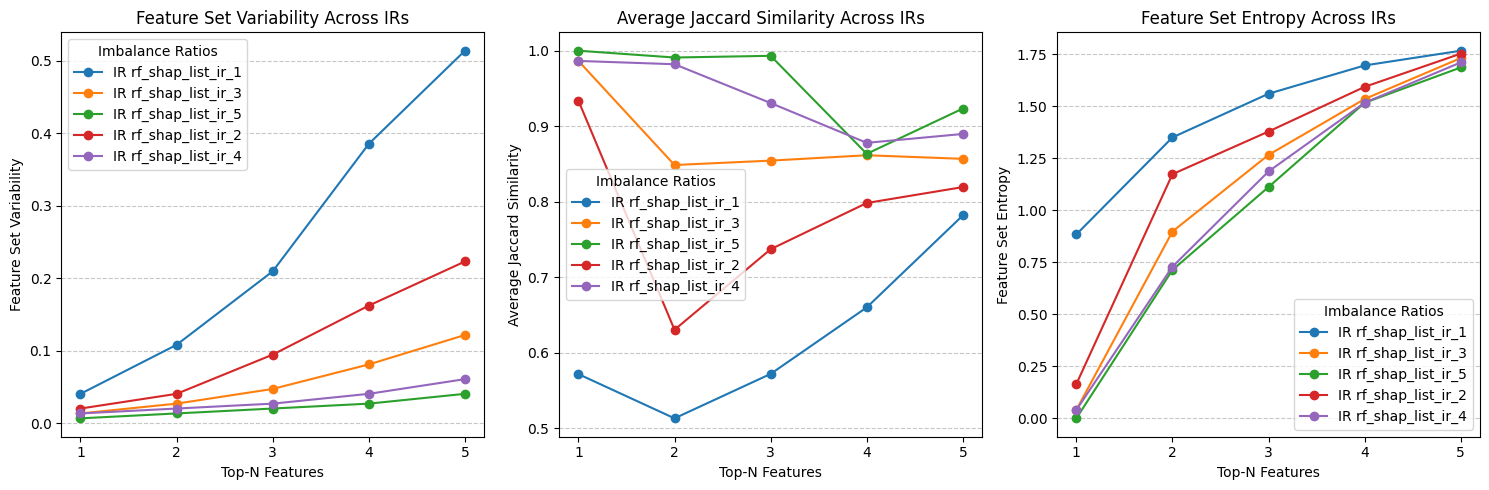

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
from sklearn.preprocessing import MultiLabelBinarizer

# Cargar el dataset
file_path = "shap_orderScore_rf.csv"
df = pd.read_csv(file_path)

# Filtrar los datos donde el indicador es 'orderMean'
filtered_df = df[df['Indicator'] == 'orderMean'][['imbalanceRatio', 'Subset', 'Sorted_Features']].copy()

# Función para extraer las k-top características de la columna Sorted_Features
def extract_top_features(dataframe, column_name, top_features_amount):
    dataframe[f'top_{top_features_amount}_features'] = dataframe[column_name].apply(
        lambda x: eval(x)[:top_features_amount] if isinstance(x, str) else x[:top_features_amount]
    )
    return dataframe

# Aplicar la función para los k-top features (k = 1 a 5)
for top_n in range(1, 6):
    filtered_df = extract_top_features(filtered_df, "Sorted_Features", top_n)

# Función para calcular la tasa de variabilidad de conjuntos de características por IR
def calculate_feature_set_variability(dataframe, group_column, list_column):
    variability_dict = {}
    
    for group, group_df in dataframe.groupby(group_column):
        unique_sets = set(tuple(row) for row in group_df[list_column])
        total_sets = len(group_df)
        variability_dict[group] = len(unique_sets) / total_sets  # Ratio de variabilidad
    
    return pd.DataFrame(list(variability_dict.items()), columns=[group_column, 'variability'])

# Función para calcular la similitud de Jaccard promedio entre subsets del mismo IR (corregida)
def calculate_jaccard_similarity(dataframe, group_column, list_column):
    jaccard_dict = {}

    for group, group_df in dataframe.groupby(group_column):
        feature_sets = [set(row) for row in group_df[list_column]]
        
        if len(feature_sets) > 1:
            # Convertir los conjuntos en una matriz binaria usando MultiLabelBinarizer
            mlb = MultiLabelBinarizer()
            binary_matrix = mlb.fit_transform(feature_sets)
            
            # Calcular la distancia de Jaccard correctamente
            jaccard_matrix = 1 - squareform(pdist(binary_matrix, metric='jaccard'))
            avg_jaccard = np.mean(jaccard_matrix[np.triu_indices(len(feature_sets), k=1)])  # Promedio sin la diagonal
        else:
            avg_jaccard = 1  # Si hay solo un subset, la similaridad es 1
        
        jaccard_dict[group] = avg_jaccard
    
    return pd.DataFrame(list(jaccard_dict.items()), columns=[group_column, 'jaccard_similarity'])

# Función para calcular la entropía de los sets de características en cada IR
def calculate_entropy(dataframe, group_column, list_column):
    entropy_dict = {}

    for group, group_df in dataframe.groupby(group_column):
        feature_sets = [tuple(row) for row in group_df[list_column]]
        _, counts = np.unique(feature_sets, return_counts=True)
        prob_dist = counts / counts.sum()
        entropy_value = entropy(prob_dist)  # Entropía de Shannon
        entropy_dict[group] = entropy_value

    return pd.DataFrame(list(entropy_dict.items()), columns=[group_column, 'entropy'])

# Calcular las métricas para k = 1 a 5
results = {}

for top_n in range(1, 6):
    results[top_n] = {
        'variability': calculate_feature_set_variability(filtered_df, "imbalanceRatio", f"top_{top_n}_features"),
        'jaccard': calculate_jaccard_similarity(filtered_df, "imbalanceRatio", f"top_{top_n}_features"),
        'entropy': calculate_entropy(filtered_df, "imbalanceRatio", f"top_{top_n}_features")
    }

# Graficar resultados
plt.figure(figsize=(15, 5))

for i, (metric_name, ylabel) in enumerate(zip(['variability', 'jaccard', 'entropy'],
                                              ['Feature Set Variability', 'Average Jaccard Similarity', 'Feature Set Entropy'])):
    plt.subplot(1, 3, i + 1)
    x_values = np.arange(1, 6)
    
    for ir_name in filtered_df['imbalanceRatio'].unique():
        y_values = [results[top_n][metric_name].set_index("imbalanceRatio").loc[ir_name].values[0] for top_n in range(1, 6)]
        plt.plot(x_values, y_values, marker='o', linestyle='-', label=f'IR {ir_name}')
    
    plt.xlabel('Top-N Features')
    plt.ylabel(ylabel)
    plt.title(ylabel + ' Across IRs')
    plt.xticks(x_values)
    plt.legend(title="Imbalance Ratios", loc="best")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


'entropy_plot_rf.png'

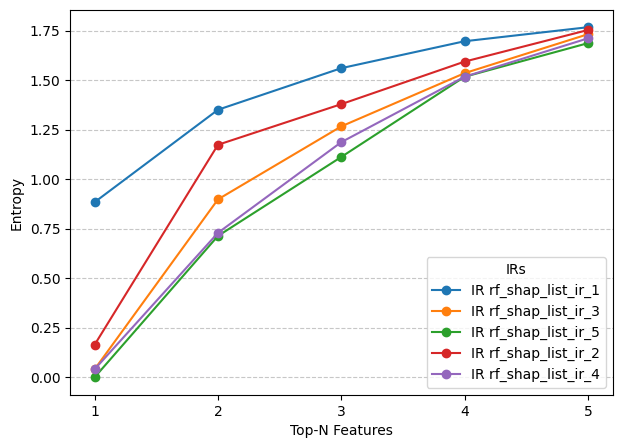

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Cargar el dataset
file_path = "shap_orderScore_rf.csv"
df = pd.read_csv(file_path)

# Filtrar los datos donde el indicador es 'orderMean'
filtered_df = df[df['Indicator'] == 'orderMean'][['imbalanceRatio', 'Subset', 'Sorted_Features']].copy()

# Función para extraer las k-top características de la columna Sorted_Features
def extract_top_features(dataframe, column_name, top_features_amount):
    dataframe[f'top_{top_features_amount}_features'] = dataframe[column_name].apply(
        lambda x: eval(x)[:top_features_amount] if isinstance(x, str) else x[:top_features_amount]
    )
    return dataframe

# Aplicar la función para los k-top features (k = 1 a 5)
for top_n in range(1, 6):
    filtered_df = extract_top_features(filtered_df, "Sorted_Features", top_n)

# Función para calcular la entropía de los sets de características en cada IR
def calculate_entropy(dataframe, group_column, list_column):
    entropy_dict = {}

    for group, group_df in dataframe.groupby(group_column):
        feature_sets = [tuple(row) for row in group_df[list_column]]
        _, counts = np.unique(feature_sets, return_counts=True)
        prob_dist = counts / counts.sum()
        entropy_value = entropy(prob_dist)  # Entropía de Shannon
        entropy_dict[group] = entropy_value

    return pd.DataFrame(list(entropy_dict.items()), columns=[group_column, 'entropy'])

# Calcular la entropía para k = 1 a 5
entropy_results = {}

for top_n in range(1, 6):
    entropy_results[top_n] = calculate_entropy(filtered_df, "imbalanceRatio", f"top_{top_n}_features")

# Graficar solo la entropía sin título y guardarlo en 600 dpi
plt.figure(figsize=(7, 5))
x_values = np.arange(1, 6)

for ir_name in filtered_df['imbalanceRatio'].unique():
    y_values = [entropy_results[top_n].set_index("imbalanceRatio").loc[ir_name].values[0] for top_n in range(1, 6)]
    plt.plot(x_values, y_values, marker='o', linestyle='-', label=f'IR {ir_name}')

plt.xlabel('Top-N Features')
plt.ylabel('Entropy')
plt.xticks(x_values)
plt.legend(title="IRs", loc="best")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Guardar la figura a 600 dpi
entropy_plot_path = "entropy_plot_rf.png"
plt.savefig(entropy_plot_path, dpi=600, bbox_inches='tight')

# Mostrar el path de la imagen generada
entropy_plot_path


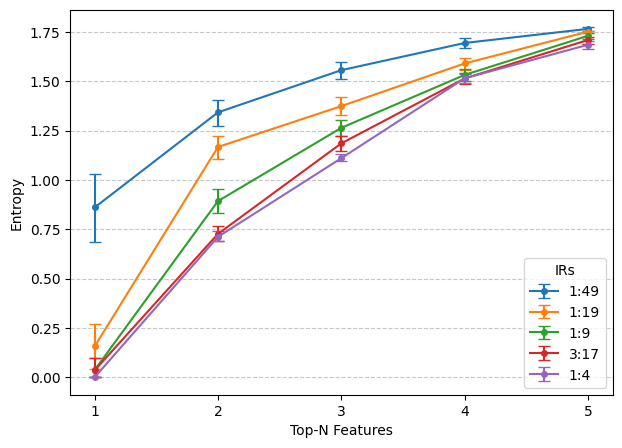

Gráfico guardado en: entropy_ci_plot_rf.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Cargar el dataset
file_path = "shap_orderScore_rf.csv"
df = pd.read_csv(file_path)

# Filtrar los datos donde el indicador es 'orderMean'
filtered_df = df[df['Indicator'] == 'orderMean'][['imbalanceRatio', 'Subset', 'Sorted_Features']].copy()

# Función para extraer las k-top características de la columna Sorted_Features
def extract_top_features(dataframe, column_name, top_features_amount):
    dataframe[f'top_{top_features_amount}_features'] = dataframe[column_name].apply(
        lambda x: eval(x)[:top_features_amount] if isinstance(x, str) else x[:top_features_amount]
    )
    return dataframe

# Aplicar la función para los k-top features (k = 1 a 5)
for top_n in range(1, 6):
    filtered_df = extract_top_features(filtered_df, "Sorted_Features", top_n)

import numpy as np, pandas as pd
from scipy.stats import entropy

def entropy_boot_ci(df, group_col, list_col, B=1000, alpha=0.05, seed=None):
    rng = np.random.default_rng(seed)
    out = []

    for g, gdf in df.groupby(group_col):
        n = len(gdf)
        boots = []
        arr = gdf[list_col].to_numpy()

        for _ in range(B):
            sample_idx = rng.choice(n, n, replace=True)
            sample_sets = [tuple(arr[i]) for i in sample_idx]
            _, counts = np.unique(sample_sets, return_counts=True)
            boots.append(entropy(counts / counts.sum(), base=np.e))

        lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
        out.append((g, np.mean(boots), lo, hi))

    return pd.DataFrame(out, columns=[group_col, 'entropy', 'ci_lower', 'ci_upper'])


ci_results = {}               # igual que antes, pero con IC incluidos

for top_n in range(1, 6):
    ci_results[top_n] = entropy_boot_ci(
        filtered_df,
        group_col="imbalanceRatio",
        list_col=f"top_{top_n}_features",
        B=2000,          # ← aumenta si quieres IC más estables
        alpha=0.05,
        seed=42
    ).assign(top_n=top_n)     # añade la k como columna

# --- 3. Consolida todo en un único DataFrame ---------------
entropy_ci_df = (pd
                 .concat(ci_results.values(), ignore_index=True)
                 .sort_values(['top_n', 'imbalanceRatio']))

shap_list_labels = ['1:49', '1:19', '1:9', '3:17', '1:4']

plt.figure(figsize=(7, 5))
x_ticks = np.arange(1, 6)

# Asegúrate de que el orden del groupby coincida con shap_list_labels
for (lab, (ir, group)) in zip(shap_list_labels, entropy_ci_df.groupby('imbalanceRatio')):
    grp = group.sort_values('top_n')
    y_vals = grp['entropy'].values
    y_err_lower = grp['entropy'] - grp['ci_lower']
    y_err_upper = grp['ci_upper'] - grp['entropy']
    plt.errorbar(grp['top_n'], y_vals,
                 yerr=[y_err_lower, y_err_upper],
                 marker='o', linestyle='-', capsize=4, markersize=4,
                 label=lab)

plt.xlabel('Top-N Features')
plt.ylabel('Entropy')
plt.xticks(x_ticks)
plt.legend(title="IRs", loc="best")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plot_path = "entropy_ci_plot_rf.png"
plt.savefig(plot_path, dpi=600, bbox_inches='tight')
plt.show()

print(f"Gráfico guardado en: {plot_path}")

'entropy_plot_corrected_rf.png'

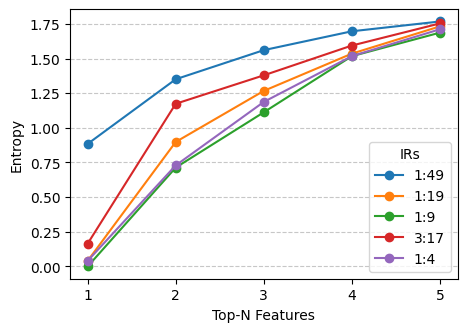

In [65]:
# Definir los nombres de los IRs según la especificación
shap_list_labels = ['1:49', '1:19', '1:9', '3:17', '1:4']

# Graficar solo la entropía con los IRs correctamente etiquetados
plt.figure(figsize=(5, 3.5))
x_values = np.arange(1, 6)

for ir_name, label in zip(filtered_df['imbalanceRatio'].unique(), shap_list_labels):
    y_values = [entropy_results[top_n].set_index("imbalanceRatio").loc[ir_name].values[0] for top_n in range(1, 6)]
    plt.plot(x_values, y_values, marker='o', linestyle='-', label=f'{label}')

plt.xlabel('Top-N Features')
plt.ylabel('Entropy')
plt.xticks(x_values)
plt.legend(title="IRs", loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Guardar la figura a 600 dpi con etiquetas de IR corregidas
entropy_plot_path = "entropy_plot_corrected_rf.png"
plt.savefig(entropy_plot_path, dpi=600, bbox_inches='tight')

# Proporcionar el enlace de descarga
entropy_plot_path


In [66]:
entropy_results

{1:       imbalanceRatio   entropy
 0  rf_shap_list_ir_1  0.884098
 1  rf_shap_list_ir_2  0.164564
 2  rf_shap_list_ir_3  0.040499
 3  rf_shap_list_ir_4  0.040499
 4  rf_shap_list_ir_5  0.000000,
 2:       imbalanceRatio   entropy
 0  rf_shap_list_ir_1  1.350461
 1  rf_shap_list_ir_2  1.173642
 2  rf_shap_list_ir_3  0.898029
 3  rf_shap_list_ir_4  0.728940
 4  rf_shap_list_ir_5  0.713397,
 3:       imbalanceRatio   entropy
 0  rf_shap_list_ir_1  1.560370
 1  rf_shap_list_ir_2  1.378737
 2  rf_shap_list_ir_3  1.266465
 3  rf_shap_list_ir_4  1.186840
 4  rf_shap_list_ir_5  1.112112,
 4:       imbalanceRatio   entropy
 0  rf_shap_list_ir_1  1.696338
 1  rf_shap_list_ir_2  1.593464
 2  rf_shap_list_ir_3  1.535125
 3  rf_shap_list_ir_4  1.517103
 4  rf_shap_list_ir_5  1.516814,
 5:       imbalanceRatio   entropy
 0  rf_shap_list_ir_1  1.767118
 1  rf_shap_list_ir_2  1.752970
 2  rf_shap_list_ir_3  1.731645
 3  rf_shap_list_ir_4  1.710834
 4  rf_shap_list_ir_5  1.686565}

In [67]:
unique_feature_lists_df['index'] = 1

In [68]:
unique_feature_lists_df22 = calculate_unique_feature_lists_per_group(unique_feature_lists_df, 'index', "unique_feature_list")

In [69]:
unique_feature_lists_df22

,index,unique_feature_list
0,1,"(X4, X6, X3, X1, X5)"
1,1,"(X4, X6, X5, X3, X1)"
2,1,"(X5, X2, X4, X6, X3)"
3,1,"(X4, X5, X1, X3, X6)"
4,1,"(X4, X6, X1, X5, X2)"
...,...,...
76,1,"(X4, X1, X6, X5, X3)"
77,1,"(X4, X5, X6, X2, X1)"
78,1,"(X4, X1, X6, X2, X3)"
79,1,"(X5, X4, X1, X2, X6)"


***
***
***
## Rand index
features order analysis (top 5 OR top 20% {for features_amount > 25}) according to mean SHAP

In [81]:
sorted_orderScore[sorted_orderScore['Indicator']=='orderMean'][['imbalanceRatio', 'Subset', 'Sorted_Features']]

,imbalanceRatio,Subset,Sorted_Features
0,shap_list_ir_1,shap_list_ir_1_subset_1000,"['AGE', 'HYPERTENSION', 'DIABETES', 'CHRONIC_K..."
3,shap_list_ir_1,shap_list_ir_1_subset_100,"['AGE', 'HYPERTENSION', 'DIABETES', 'CHRONIC_K..."
6,shap_list_ir_1,shap_list_ir_1_subset_101,"['AGE', 'HYPERTENSION', 'DIABETES', 'SEX_FEMAL..."
9,shap_list_ir_1,shap_list_ir_1_subset_102,"['AGE', 'HYPERTENSION', 'DIABETES', 'ARTHROSIS..."
12,shap_list_ir_1,shap_list_ir_1_subset_103,"['AGE', 'HYPERTENSION', 'DIABETES', 'DEMENTIA'..."
...,...,...,...
14985,shap_list_ir_5,shap_list_ir_5_subset_997,"['AGE', 'HYPERTENSION', 'DIABETES', 'HEART_FAI..."
14988,shap_list_ir_5,shap_list_ir_5_subset_998,"['AGE', 'HYPERTENSION', 'DIABETES', 'HEART_FAI..."
14991,shap_list_ir_5,shap_list_ir_5_subset_999,"['AGE', 'HYPERTENSION', 'DIABETES', 'CHRONIC_K..."
14994,shap_list_ir_5,shap_list_ir_5_subset_99,"['AGE', 'HYPERTENSION', 'DIABETES', 'DEMENTIA'..."


In [ ]:
%%time
import pandas as pd
from sklearn.metrics.cluster import adjusted_rand_score


data = sorted_orderScore

# Initialize a dictionary to store results
results = []

# Iterate through each unique imbalanceRatio
for imbalance_ratio in data['imbalanceRatio'].unique():
    # Filter the DataFrame for the current imbalanceRatio
    subset_data = data[data['imbalanceRatio'] == imbalance_ratio]

    for _, row in subset_data.iterrows():
        # Extract the first 5 features from the Sorted_Features column
        sorted_features = eval(row['Sorted_Features'])  # Convert string representation of list to actual list
        top_5_features = sorted_features[:5]

        # Calculate Rand index (example calculation, modify as per actual use case)
        # Here, we're using random example data. Replace with your actual logic if needed.
        # Assume we compare top_5_features with a reference set of features
        reference_features = ['AGE', 'HYPERTENSION', 'Mammography', 'CHRONIC_KIDNEY_DISEASE', 'HEART_FAILURE']
        rand_index = adjusted_rand_score(top_5_features, reference_features)

        # Append results
        results.append({
            'imbalanceRatio': imbalance_ratio,
            'Subset': row['Subset'],
            'RandIndex': rand_index,
            'Top5Features': top_5_features
        })

# Create a results DataFrame
results_df = pd.DataFrame(results)

# Save the results to a new CSV file
# results_df.to_csv("rand_index_results.csv", index=False)

# print("Rand index calculation completed. Results saved to 'rand_index_results.csv'.")


Wall time: 18.3 s


In [83]:
results_df

,imbalanceRatio,Subset,RandIndex,Top5Features
0,shap_list_ir_1,shap_list_ir_1_subset_1000,1.0,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D..."
1,shap_list_ir_1,shap_list_ir_1_subset_1000,1.0,"[AGE, DIABETES, HYPERTENSION, CHRONIC_KIDNEY_D..."
2,shap_list_ir_1,shap_list_ir_1_subset_1000,1.0,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D..."
3,shap_list_ir_1,shap_list_ir_1_subset_100,1.0,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D..."
4,shap_list_ir_1,shap_list_ir_1_subset_100,1.0,"[AGE, DIABETES, HYPERTENSION, ARTHROSIS, STROKE]"
...,...,...,...,...
14995,shap_list_ir_5,shap_list_ir_5_subset_99,1.0,"[AGE, DIABETES, DEMENTIA, HEART_FAILURE, HYPER..."
14996,shap_list_ir_5,shap_list_ir_5_subset_99,1.0,"[AGE, HYPERTENSION, DIABETES, DEMENTIA, CHRONI..."
14997,shap_list_ir_5,shap_list_ir_5_subset_9,1.0,"[AGE, HYPERTENSION, DIABETES, DEMENTIA, CHRONI..."
14998,shap_list_ir_5,shap_list_ir_5_subset_9,1.0,"[AGE, DIABETES, DEMENTIA, CHRONIC_KIDNEY_DISEA..."


In [84]:
results_df.describe()

,RandIndex
count,15000.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


# TEMP/Trash

## Association rules

https://towardsdatascience.com/association-rules-2-aa9a77241654

In [34]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

def calculate_association_rules(df, num_features, indicators):
    """
    Calculate association rules for the first `num_features` in the "Sorted_Features" column.

    Parameters:
        df (pd.DataFrame): Input DataFrame with columns 'Indicator', 'Sorted_Features', 'imbalanceRatio', and 'Subset'.
        num_features (int): Number of features to select for analysis from 'Sorted_Features'.
        indicators (list): List of indicators to filter on (e.g., ['orderMean', 'orderStd']).

    Returns:
        dict: A dictionary containing association rules for each subset and imbalance ratio.
    """
    # Filter the DataFrame by the specified indicators
    filtered_df = df[df['Indicator'].isin(indicators)]

    results = {}

    
    
    
    for (imbalance_ratio, subset), group in filtered_df.groupby(['imbalanceRatio', 'Subset']):
        # Extract the first `num_features` from "Sorted_Features" column
        features = group['Sorted_Features'].apply(lambda x: x[:num_features])

        # Create a one-hot encoded DataFrame for the features
        feature_set = pd.DataFrame(features.tolist()).stack().reset_index()
        feature_set.columns = ['row', 'feature_index', 'feature']
        one_hot = pd.crosstab(feature_set['row'], feature_set['feature']).astype(bool)

        # Apply the Apriori algorithm to find frequent itemsets
        frequent_itemsets = apriori(one_hot, min_support=0.1, use_colnames=True)

        # Generate association rules
        rules = association_rules(frequent_itemsets, metric='support', min_threshold=0.1,num_itemsets = 1000, support_only =True)

        # Store the rules in the results dictionary
        results[(imbalance_ratio, subset)] = rules

    return results

# # Example Usage
# # Assuming `sorted_orderScore` is your DataFrame
# # Define the number of features to analyze
# num_features = 5

# # Define the indicators to analyze
# indicators = ['orderMean', 'orderStd']

# # Call the function
# rules = calculate_association_rules(sorted_orderScore, num_features, indicators)

# # Print the rules for each (imbalanceRatio, Subset) combination
# for key, value in rules.items():
#     print(f"Rules for {key}:\n", value)

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### Test dataset for imbalance ratio 1

In [26]:
ir1 = sorted_orderScore[sorted_orderScore['imbalanceRatio'] == 'shap_list_ir_1'].copy()

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [35]:
%%time
# Define the number of features to analyze
num_features = 5

# Define the indicators to analyze
indicators = ['orderMean']

# Call the function
rules = calculate_association_rules(ir1, num_features, indicators)

# Print the rules for each (imbalanceRatio, Subset) combination
for key, value in rules.items():
    print(f"Rules for {key}:\n", value)

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Rules for ('shap_list_ir_1', 'shap_list_ir_1_subset_1'):
 Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []
Rules for ('shap_list_ir_1', 'shap_list_ir_1_subset_10'):
 Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []
Rules for ('shap_list_ir_1', 'shap_list_ir_1_subset_100'):
 Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []
Rules for ('shap_list_ir_1', 'shap_list_ir_1_subset_1000'):
 Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, l

In [31]:
rules

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [42]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

def calculate_support_confidence(df, num_features):
    """
    Calculate support and confidence for the first `num_features` in the "Sorted_Features" column.

    Parameters:
        df (pd.DataFrame): Input DataFrame with column 'Sorted_Features'.
        num_features (int): Number of features to select for analysis from 'Sorted_Features'.

    Returns:
        pd.DataFrame: A DataFrame containing the support and confidence of the most frequent names and their relations.
    """
    results = []

    for idx, row in df.iterrows():
        # Extract the first `num_features` from "Sorted_Features" column
        top_features = row['Sorted_Features'][:num_features]

        # Create a one-hot encoded DataFrame for the features
        feature_set = pd.DataFrame([top_features], columns=top_features).notna()

        # Apply the Apriori algorithm to find frequent itemsets
        frequent_itemsets = apriori(feature_set, min_support=0.1, use_colnames=True)

        # Generate association rules (only support and confidence)
        rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.1)
        rules = rules[['antecedents', 'consequents', 'support', 'confidence']]

        # Append rules to the results
        results.append(rules)

    # Combine all results into a single DataFrame
    combined_results = pd.concat(results, ignore_index=True)

    return combined_results

# # Example Usage
# # Assuming `sorted_orderScore` is your DataFrame
# # Define the number of features to analyze
# num_features = 5

# # Call the function
# support_confidence_results = calculate_support_confidence(sorted_orderScore, num_features)

# # Print the results
# print(support_confidence_results)


C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [44]:
ir1

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,imbalanceRatio,Subset,Indicator,Sorted_Features
0,shap_list_ir_1,shap_list_ir_1_subset_1000,orderMean,"['ARTHRITIS', 'CIRRHOSIS', 'OBESITY', 'DEPRESS..."
1,shap_list_ir_1,shap_list_ir_1_subset_1000,orderStd,"['ARTHRITIS', 'OBESITY', 'DEPRESSION', 'ARTHRO..."
2,shap_list_ir_1,shap_list_ir_1_subset_1000,orderSum,"['AGE', 'HYPERTENSION', 'DIABETES', 'CHRONIC_K..."
3,shap_list_ir_1,shap_list_ir_1_subset_100,orderMean,"['ARTHRITIS', 'OSTEOPOROSIS', 'CIRRHOSIS', 'AS..."
4,shap_list_ir_1,shap_list_ir_1_subset_100,orderStd,"['ARTHRITIS', 'SEX_FEMALE', 'OBESITY', 'COPD',..."
...,...,...,...,...
2995,shap_list_ir_1,shap_list_ir_1_subset_99,orderStd,"['HEART_FAILURE', 'DEPRESSION', 'SEX_FEMALE', ..."
2996,shap_list_ir_1,shap_list_ir_1_subset_99,orderSum,"['AGE', 'HYPERTENSION', 'DIABETES', 'OBESITY',..."
2997,shap_list_ir_1,shap_list_ir_1_subset_9,orderMean,"['OSTEOPOROSIS', 'OBESITY', 'ASTHMA', 'ARTHRIT..."
2998,shap_list_ir_1,shap_list_ir_1_subset_9,orderStd,"['OBESITY', 'SEX_FEMALE', 'OSTEOPOROSIS', 'ISC..."


In [43]:
%%time
# Assuming `sorted_orderScore` is your DataFrame
# Define the number of features to analyze
num_features = 5

# Call the function
support_confidence_results = calculate_support_confidence(sorted_orderScore, num_features)


C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


TypeError: Index(...) must be called with a collection of some kind, "['ART" was passed

In [41]:
support_confidence_results

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


NameError: name 'support_confidence_results' is not defined

# Paper results

In [ ]:
import pandas as pd
import scipy.stats as stats
import itertools
import os

# Lista de identificadores de datasets
dataset_identifiers = ["Covid_code", "Mammography_code", "Mammography_code", "Mammography_code", "Satimage_code"]

# Ruta base de los archivos
base_path = "/Users/antonio/Desktop/Conference Paper SHAP Maciej actualizado/newResults"

# Lista para almacenar los rankings de cada dataset
all_rankings = []

for dataset in dataset_identifiers:
    file_path = os.path.join(base_path, dataset, "sorted_orderValuesScore.csv")

    # Cargar el dataset
    sorted_orderValuesScore = pd.read_csv(file_path)
    sorted_orderValuesScore.drop("Unnamed: 0", axis=1, inplace=True)
    sorted_orderValuesScore.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

    # Obtener valores únicos de IRs y features
    imbalance_ratios = sorted_orderValuesScore['imbalance_ratio'].unique()
    features = sorted_orderValuesScore['feature'].unique()

    # Diccionario para almacenar rankings
    rankings_dict = {feature: {} for feature in features}

    for feature in features:
        # Filtrar datos por la feature
        feature_data = sorted_orderValuesScore[sorted_orderValuesScore['feature'] == feature]

        # Calcular la media de shapMean por IR
        means = feature_data.groupby('imbalance_ratio')['shapMean'].mean().sort_values(ascending=False)

        # Matriz de significancia
        significance_matrix = pd.DataFrame(1.0, index=imbalance_ratios, columns=imbalance_ratios)

        # Pruebas t pareadas
        for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
            group1 = feature_data[feature_data['imbalance_ratio'] == ir1]['shapMean']
            group2 = feature_data[feature_data['imbalance_ratio'] == ir2]['shapMean']

            if len(group1) > 1 and len(group2) > 1:  # Asegurar suficientes datos
                stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)  # Welch’s t-test
            else:
                p_value = 1  # Asumir no diferencia si no hay suficientes datos

            # Almacenar p-valor
            significance_matrix.loc[ir1, ir2] = p_value
            significance_matrix.loc[ir2, ir1] = p_value

        # Asignar rankings iniciales basados en las medias
        ranking_values = {ir: rank + 1 for rank, ir in enumerate(means.index)}

        # Ajustar rankings si no hay diferencias significativas
        for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
            if significance_matrix.loc[ir1, ir2] >= 0.05:  # No diferencia significativa
                min_rank = min(ranking_values[ir1], ranking_values[ir2])
                ranking_values[ir1] = ranking_values[ir2] = min_rank

        rankings_dict[feature] = ranking_values

    # Convertir rankings a DataFrame
    ranking_table = pd.DataFrame(rankings_dict).T.fillna(0)

    # Reordenar las columnas por número de IR
    sorted_columns = sorted(ranking_table.columns, key=lambda x: int(x.split('_')[-1]))
    ranking_table = ranking_table[sorted_columns]
    
    # Agregar columna con nombre del dataset
    ranking_table["Dataset"] = dataset

    # Guardar resultados en la lista
    all_rankings.append(ranking_table)

# Concatenar todos los rankings en un solo DataFrame
final_ranking_table = pd.concat(all_rankings).reset_index().rename(columns={"index": "Feature"})

# Mostrar resultado
import ace_tools_open as tools
tools.display_dataframe_to_user(name="Combined Adjusted Ranking of the mean by IR for shapMeans", dataframe=final_ranking_table)


Combined Adjusted Ranking of the mean by IR for shapMeans


In [ ]:
import pandas as pd
import scipy.stats as stats
import itertools
import os

# Lista de identificadores de datasets
dataset_identifiers = ["Covid_code", "Mammography_code", "Mammography_code", "Mammography_code", "Satimage_code"]

# Ruta base de los archivos
base_path = "/Users/antonio/Desktop/Conference Paper SHAP Maciej actualizado/newResults"

# Lista para almacenar los rankings de cada dataset
all_rankings = []

for dataset in dataset_identifiers:
    file_path = os.path.join(base_path, dataset, "sorted_orderValuesScore.csv")

    # Cargar el dataset
    sorted_orderValuesScore = pd.read_csv(file_path)
    sorted_orderValuesScore.drop("Unnamed: 0", axis=1, inplace=True)
    sorted_orderValuesScore.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

    # Obtener valores únicos de IRs y features
    imbalance_ratios = sorted_orderValuesScore['imbalance_ratio'].unique()
    features = sorted_orderValuesScore['feature'].unique()
    num_features = len(features)
    # Diccionario para almacenar rankings
    rankings_dict = {feature: {} for feature in features}

    for feature in features:
        # Filtrar datos por la feature
        feature_data = sorted_orderValuesScore[sorted_orderValuesScore['feature'] == feature]

        # Calcular la media de shapMean por IR
        means = feature_data.groupby('imbalance_ratio')['shapMean'].mean().sort_values(ascending=False)

        # Matriz de significancia
        significance_matrix = pd.DataFrame(1.0, index=imbalance_ratios, columns=imbalance_ratios)
        comparisons = itertools.combinations(imbalance_ratios, 2)
        comp_len = 10
        # Pruebas t pareadas
        for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
            group1 = feature_data[feature_data['imbalance_ratio'] == ir1]['shapMean']
            group2 = feature_data[feature_data['imbalance_ratio'] == ir2]['shapMean']

            if len(group1) > 1 and len(group2) > 1:  # Asegurar suficientes datos
                stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)  # Welch’s t-test
                p_value *= comp_len
            else:
                p_value = 1  # Asumir no diferencia si no hay suficientes datos

            # Almacenar p-valor
            significance_matrix.loc[ir1, ir2] = p_value
            significance_matrix.loc[ir2, ir1] = p_value

        # Asignar rankings iniciales basados en las medias
        ranking_values = {ir: rank + 1 for rank, ir in enumerate(means.index)}

        # Ajustar rankings si no hay diferencias significativas
        for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
            if significance_matrix.loc[ir1, ir2] >= 0.05:  # No diferencia significativa
                min_rank = min(ranking_values[ir1], ranking_values[ir2])
                ranking_values[ir1] = ranking_values[ir2] = min_rank

        rankings_dict[feature] = ranking_values

    # Convertir rankings a DataFrame
    ranking_table = pd.DataFrame(rankings_dict).T.fillna(0)

    # Reordenar las columnas por número de IR
    sorted_columns = sorted(ranking_table.columns, key=lambda x: int(x.split('_')[-1]))
    ranking_table = ranking_table[sorted_columns]
    
    # Agregar columna con nombre del dataset
    ranking_table["Dataset"] = dataset

    # Guardar resultados en la lista
    all_rankings.append(ranking_table)

# Concatenar todos los rankings en un solo DataFrame
final_ranking_table = pd.concat(all_rankings).reset_index().rename(columns={"index": "Feature"})

# Mostrar resultado
import ace_tools_open as tools
tools.display_dataframe_to_user(name="Combined Adjusted Ranking of the mean by IR for shapMeans", dataframe=final_ranking_table)



TypeError: mannwhitneyu() got an unexpected keyword argument 'equal_var'

In [4]:
comparisons = itertools.combinations(imbalance_ratios, 2)
for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
    print(ir1)

shap_list_ir_2
shap_list_ir_2
shap_list_ir_2
shap_list_ir_2
shap_list_ir_4
shap_list_ir_4
shap_list_ir_4
shap_list_ir_3
shap_list_ir_3
shap_list_ir_1


In [6]:
medias = final_ranking_table.iloc[:, 1:-1].mean()

print(medias)

shap_list_ir_1    1.695652
shap_list_ir_2    1.684783
shap_list_ir_3    1.641304
shap_list_ir_4    1.706522
shap_list_ir_5    1.706522
dtype: float64


In [6]:
# Suponiendo que final_ranking_table ya tiene las columnas 'shap_list_ir_1' a 'shap_list_ir_5'
# Si estas columnas vienen de los nombres de las IR en el CSV, asegúrate de que correspondan.
# En caso de que tengan otro nombre, ajusta la lista de columnas.

# Lista de columnas a promediar:

cols_ir = [col for col in final_ranking_table.columns if col.startswith("shap_list_ir_")]

# Calcular la media por dataset:
mean_by_dataset = final_ranking_table.groupby("Dataset")[cols_ir].mean()

# Calcular la media global (todos los datasets juntos):
mean_all = final_ranking_table[cols_ir].mean().to_frame().T
mean_all.index = ["All_Datasets"]

# Concatenar ambos resultados en un solo dataframe:
result_df = pd.concat([mean_by_dataset, mean_all])

# Mostrar el resultado:
print(result_df)


                  shap_list_ir_1  shap_list_ir_2  shap_list_ir_3  \
Covid_code              2.529412        2.705882        2.882353   
Diabetes_code           2.000000        1.750000        2.250000   
Forest_code             1.880000        2.120000        2.000000   
Mammography_code        2.166667        2.333333        2.000000   
Satimage_code           1.777778        1.527778        1.583333   
All_Datasets            1.989130        1.978261        2.021739   

                  shap_list_ir_4  shap_list_ir_5  
Covid_code              2.705882        2.647059  
Diabetes_code           2.625000        3.125000  
Forest_code             2.040000        2.120000  
Mammography_code        2.666667        2.833333  
Satimage_code           1.722222        2.000000  
All_Datasets            2.130435        2.304348  


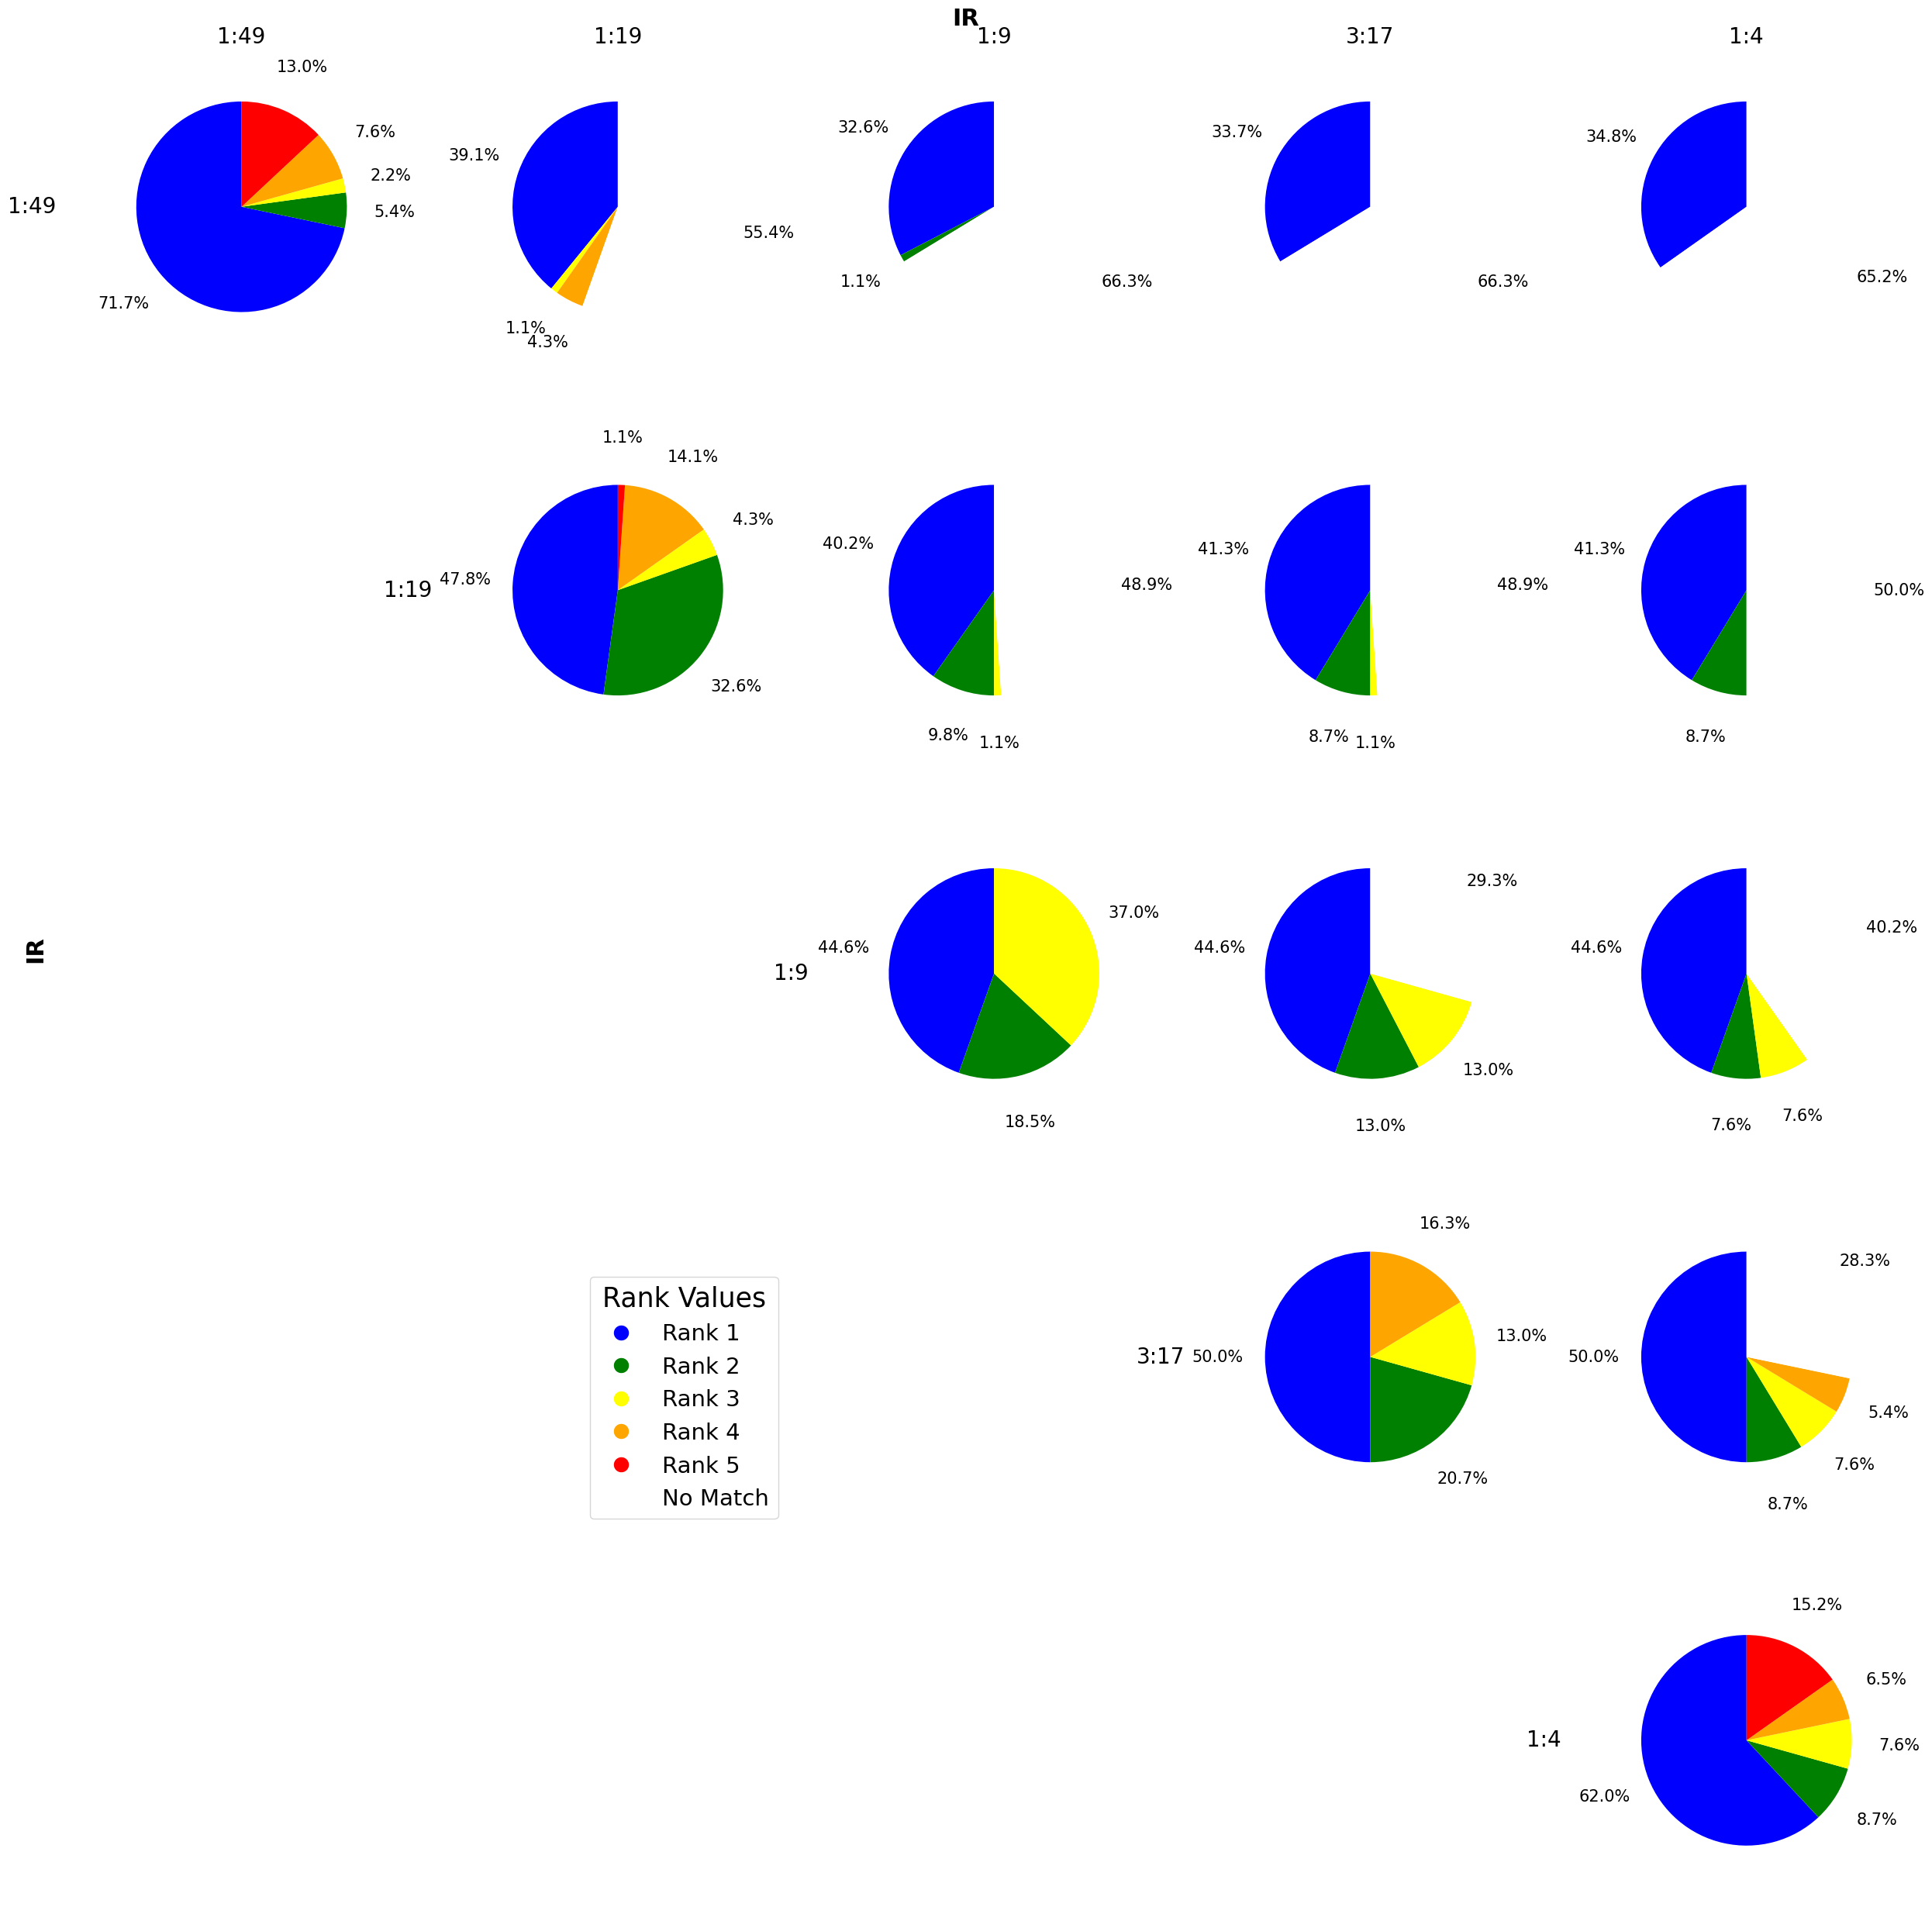

In [14]:
import numpy as np
import matplotlib.pyplot as plt

num_irs = 5
shap_list_labels = ['1:49', '1:19', '1:9', '3:17', '1:4']

rank_colors = {1: 'blue', 2: 'green', 3: 'yellow', 4: 'orange', 5: 'red'}
mismatch_color = 'white'  # Color for non-matching ranks

# Filtrar solo columnas de IRs
ir_columns = [col for col in final_ranking_table.columns if col not in ["Feature", "Dataset"]]
ranking_table_filtered = final_ranking_table[ir_columns]

fig, axes = plt.subplots(num_irs, num_irs, figsize=(25, 25))

num_variables = ranking_table_filtered.shape[0]

for i in range(num_irs):
    for j in range(num_irs):
        ax = axes[i, j]

        if j < i:
            ax.axis("off")
            continue

        if i == j:
            values, counts = np.unique(ranking_table_filtered.iloc[:, i].dropna().astype(int), return_counts=True)
            colors = [rank_colors.get(v, mismatch_color) for v in values]
        else:
            matching_counts = {rank: 0 for rank in rank_colors.keys()}

            for var in range(num_variables):
                rank_i = ranking_table_filtered.iloc[var, i]
                rank_j = ranking_table_filtered.iloc[var, j]
                if rank_i == rank_j:
                    matching_counts[rank_i] += 1

            values = [rank for rank, count in matching_counts.items() if count > 0]
            counts = [count / num_variables for rank, count in matching_counts.items() if count > 0]

            mismatch_proportion = 1 - sum(counts)
            if mismatch_proportion > 0:
                values.append(0)
                counts.append(mismatch_proportion)

            colors = [rank_colors.get(v, mismatch_color) for v in values]

        if len(values) > 0:
            ax.pie(counts, labels=None, autopct='%1.1f%%', colors=colors, startangle=90,
                   textprops={'fontsize': 15}, pctdistance=1.45)
        else:
            ax.axis("off")

        if j == i:
            ax.set_ylabel(shap_list_labels[i], rotation=0, labelpad=50, fontsize=20, ha='right', va='center')

# Añadir 'IR' en la parte superior del eje X
for ax, col in zip(axes[0], shap_list_labels):
    ax.set_title(col, fontsize=20, pad=30)

fig.text(0.5, 0.98, 'IR', ha='center', va='center', fontsize=22, fontweight='bold')

# Añadir 'IR' en la parte izquierda del eje Y
fig.text(0.02, 0.5, 'IR', ha='center', va='center', rotation=90, fontsize=22, fontweight='bold')

# Leyenda
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=15) for color in rank_colors.values()]
handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=15))  # "No Match"

labels = [f"Rank {k}" for k in rank_colors.keys()] + ["No Match"]
fig.legend(handles, labels, title="Rank Values", loc="lower left", bbox_to_anchor=(0.3, 0.2), fontsize=21, title_fontsize=25)

plt.tight_layout()

# Guardar imagen con 600 dpi
plt.savefig("ranking_heatmap_bonf.png", dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd
import scipy.stats as stats
import itertools
import os

# Lista de identificadores de datasets
dataset_identifiers = ["Covid_code", "Mammography_code", "Mammography_code", "Mammography_code", "Satimage_code"]

# Ruta base de los archivos
base_path = "/Users/antonio/Desktop/Conference Paper SHAP Maciej actualizado/newResults"

# Lista para almacenar los rankings de cada dataset
all_rankings_std = []

for dataset in dataset_identifiers:
    file_path = os.path.join(base_path, dataset, "sorted_orderValuesScore.csv")

    # Cargar el dataset
    sorted_orderValuesScore = pd.read_csv(file_path)
    sorted_orderValuesScore.drop("Unnamed: 0", axis=1, inplace=True)
    sorted_orderValuesScore.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

    # Obtener valores únicos de IRs y features
    imbalance_ratios = sorted_orderValuesScore['imbalance_ratio'].unique()
    features = sorted_orderValuesScore['feature'].unique()
    features_num = len(features)
    # Diccionario para almacenar rankings
    rankings_std_dict = {feature: {} for feature in features}

    for feature in features:
        # Filtrar datos por la feature
        feature_data = sorted_orderValuesScore[sorted_orderValuesScore['feature'] == feature]

        # Calcular la desviación estándar de shapMean por IR
        std_devs = feature_data.groupby('imbalance_ratio')['shapMean'].std().sort_values(ascending=False)

        # Matriz de significancia
        significance_matrix = pd.DataFrame(1.0, index=imbalance_ratios, columns=imbalance_ratios)

        # Pruebas de Levene para comparar varianzas
        for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
            group1 = feature_data[feature_data['imbalance_ratio'] == ir1]['shapMean']
            group2 = feature_data[feature_data['imbalance_ratio'] == ir2]['shapMean']

            if len(group1) > 1 and len(group2) > 1:  # Asegurar suficientes datos
                stat, p_value = stats.levene(group1, group2, center='median')  # Levene’s test
                p_value *= 10
            else:
                p_value = 1  # Asumir no diferencia si no hay suficientes datos

            # Almacenar p-valor
            significance_matrix.loc[ir1, ir2] = p_value
            significance_matrix.loc[ir2, ir1] = p_value

        # Asignar rankings iniciales basados en las desviaciones estándar
        ranking_values = {ir: rank + 1 for rank, ir in enumerate(std_devs.index)}

        # Ajustar rankings si no hay diferencias significativas
        for ir1, ir2 in itertools.combinations(imbalance_ratios, 2):
            if significance_matrix.loc[ir1, ir2] >= 0.05:  # No diferencia significativa
                min_rank = min(ranking_values[ir1], ranking_values[ir2])
                ranking_values[ir1] = ranking_values[ir2] = min_rank

        rankings_std_dict[feature] = ranking_values

    # Convertir rankings a DataFrame
    ranking_std_table = pd.DataFrame(rankings_std_dict).T.fillna(0)

    # Agregar columna con nombre del dataset
    ranking_std_table["Dataset"] = dataset

    # Guardar resultados en la lista
    all_rankings_std.append(ranking_std_table)

# Concatenar todos los rankings en un solo DataFrame
final_ranking_std_table = pd.concat(all_rankings_std).reset_index().rename(columns={"index": "Feature"})

# Mostrar resultado
import ace_tools_open as tools
tools.display_dataframe_to_user(name="Combined Adjusted Ranking of the variance by IR for shapMeans", dataframe=final_ranking_std_table)


Combined Adjusted Ranking of the variance by IR for shapMeans


In [12]:
# Suponiendo que final_ranking_table ya tiene las columnas 'shap_list_ir_1' a 'shap_list_ir_5'
# Si estas columnas vienen de los nombres de las IR en el CSV, asegúrate de que correspondan.
# En caso de que tengan otro nombre, ajusta la lista de columnas.

# Lista de columnas a promediar:

cols_ir = [col for col in final_ranking_std_table.columns if col.startswith("shap_list_ir_")]

# Calcular la media por dataset:
mean_by_dataset = final_ranking_std_table.groupby("Dataset")[cols_ir].mean()

# Calcular la media global (todos los datasets juntos):
mean_all = final_ranking_std_table[cols_ir].mean().to_frame().T
mean_all.index = ["All_Datasets"]

# Concatenar ambos resultados en un solo dataframe:
result_df = pd.concat([mean_by_dataset, mean_all])

# Mostrar el resultado:
print(result_df)



                  shap_list_ir_1  shap_list_ir_2  shap_list_ir_3  \
Covid_code                   1.0        2.000000        3.000000   
Diabetes_code                1.0        1.500000        2.750000   
Forest_code                  1.0        1.640000        2.280000   
Mammography_code             1.0        1.833333        2.833333   
Satimage_code                1.0        1.500000        2.722222   
All_Datasets                 1.0        1.652174        2.663043   

                  shap_list_ir_4  shap_list_ir_5  
Covid_code              4.000000        5.000000  
Diabetes_code           3.125000        3.750000  
Forest_code             2.280000        2.520000  
Mammography_code        3.500000        4.833333  
Satimage_code           3.166667        4.277778  
All_Datasets            3.097826        3.923913  


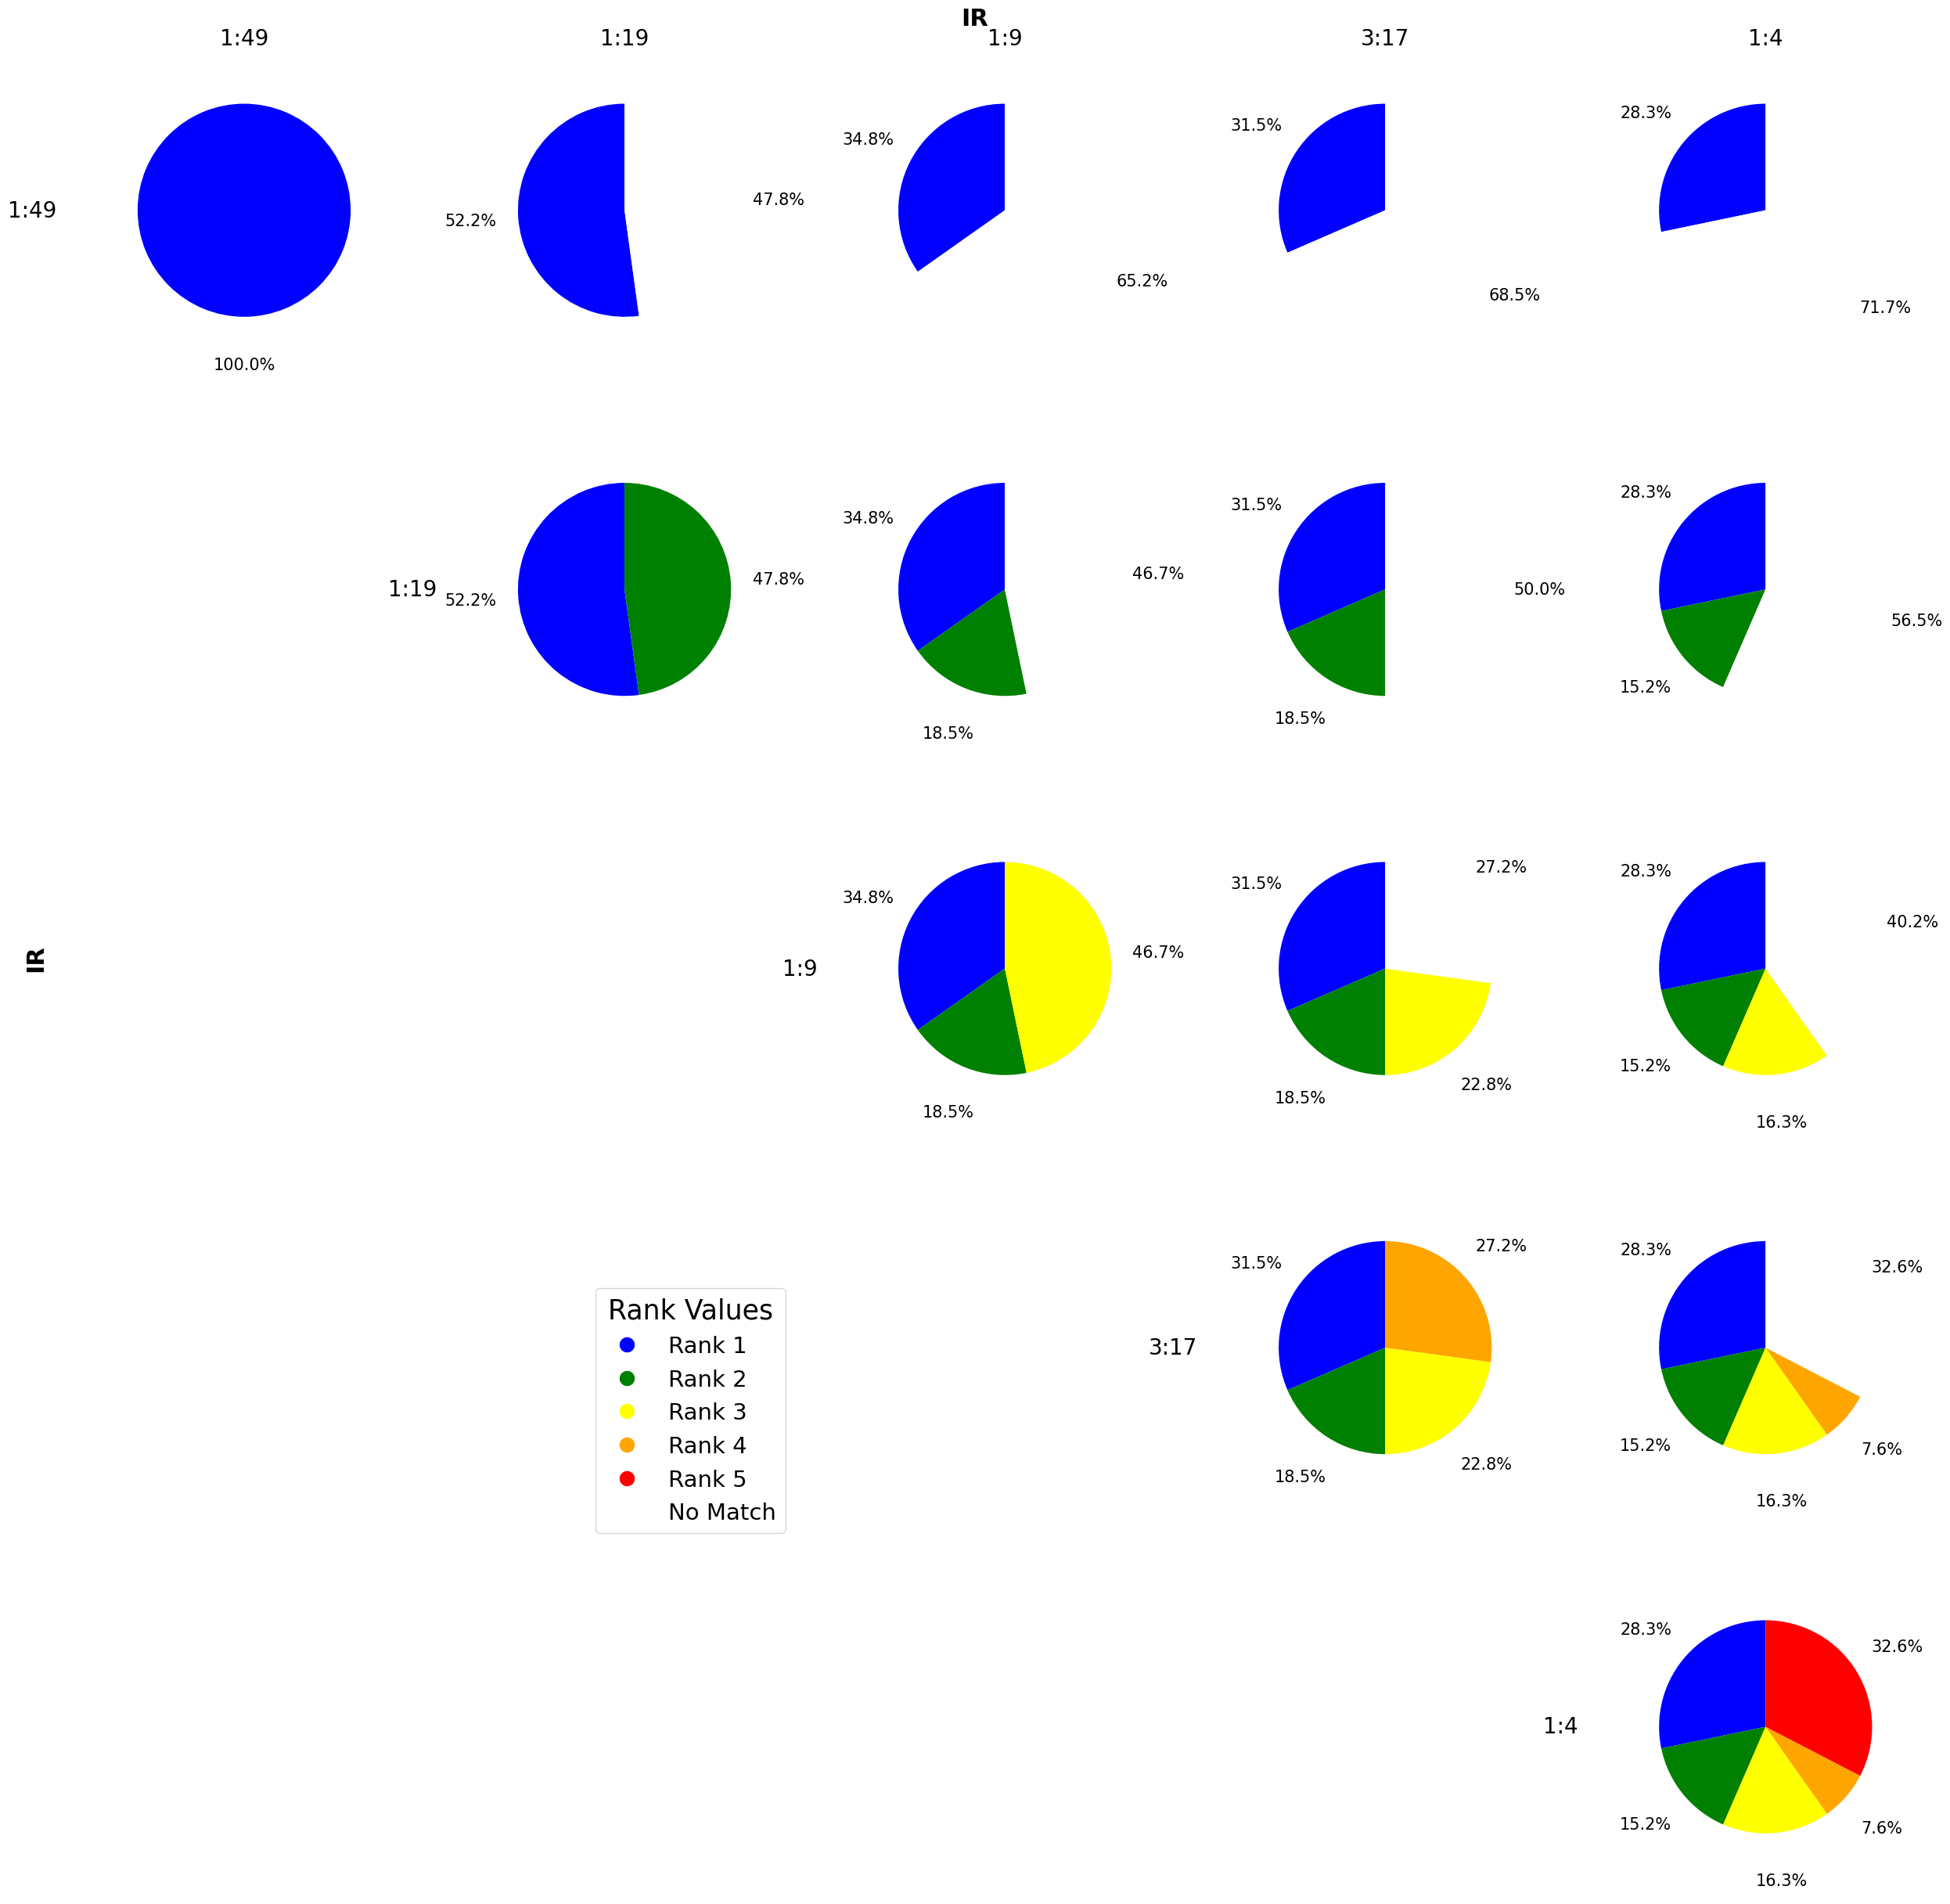

In [12]:
import numpy as np
import matplotlib.pyplot as plt

num_irs = 5
shap_list_labels = ['1:49', '1:19', '1:9', '3:17', '1:4']

rank_colors = {1: 'blue', 2: 'green', 3: 'yellow', 4: 'orange', 5: 'red'}
mismatch_color = 'white'  # Color para valores no coincidentes


# Filtrar solo columnas de IRs
ir_columns = [col for col in final_ranking_std_table.columns if col not in ["Feature", "Dataset"]]
ranking_std_table_filtered = final_ranking_std_table[ir_columns]

fig, axes = plt.subplots(num_irs, num_irs, figsize=(25, 25))

num_variables = ranking_std_table_filtered.shape[0]

for i in range(num_irs):
    for j in range(num_irs):
        ax = axes[i, j]

        if j < i:
            ax.axis("off")
            continue

        if i == j:
            values, counts = np.unique(ranking_std_table_filtered.iloc[:, i].dropna().astype(int), return_counts=True)
            colors = [rank_colors.get(v, mismatch_color) for v in values]
        else:
            matching_counts = {rank: 0 for rank in rank_colors.keys()}

            for var in range(num_variables):
                rank_i = ranking_std_table_filtered.iloc[var, i]
                rank_j = ranking_std_table_filtered.iloc[var, j]

                if rank_i == rank_j:
                    matching_counts[rank_i] += 1

            values = [rank for rank, count in matching_counts.items() if count > 0]
            counts = [count / num_variables for rank, count in matching_counts.items() if count > 0]

            mismatch_proportion = 1 - sum(counts)
            if mismatch_proportion > 0:
                values.append(0)
                counts.append(mismatch_proportion)

            colors = [rank_colors.get(v, mismatch_color) for v in values]

        if len(values) > 0:
            ax.pie(counts, labels=None, autopct='%1.1f%%', colors=colors, startangle=90,
                   textprops={'fontsize': 15}, pctdistance=1.45)
        else:
            ax.axis("off")

        if j == i:
            ax.set_ylabel(shap_list_labels[i], rotation=0, labelpad=50, fontsize=20, ha='right', va='center')

# Añadir 'IR' en la parte superior del eje X
for ax, col in zip(axes[0], shap_list_labels):
    ax.set_title(col, fontsize=20, pad=30)

fig.text(0.5, 0.98, 'IR', ha='center', va='center', fontsize=22, fontweight='bold')

# Añadir 'IR' en la parte izquierda del eje Y
fig.text(0.02, 0.5, 'IR', ha='center', va='center', rotation=90, fontsize=22, fontweight='bold')

# Leyenda
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=15) for color in rank_colors.values()]
handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=15))  # "No Match"

labels = [f"Rank {k}" for k in rank_colors.keys()] + ['No Match']
fig.legend(handles, labels, title="Rank Values", loc="lower left", bbox_to_anchor=(0.3, 0.2), fontsize=21, title_fontsize=25)

plt.tight_layout()

# Guardar imagen con 600 dpi
plt.savefig("variance_ranking_heatmap_bonf.png", dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
file_path = "/Users/antonio/Desktop/Conference Paper SHAP Maciej actualizado/Mammography/metrics_summary.parquet"

# Cargar el archivo Parquet en un DataFrame de pandas
df = pd.read_parquet(file_path)
print(df)

                 Dataset  Balanced Accuracy  Accuracy  Cohen's Kappa  \
0      IR_1_subset_1.csv           1.000000  1.000000       1.000000   
1      IR_1_subset_2.csv           1.000000  1.000000       1.000000   
2      IR_1_subset_3.csv           1.000000  1.000000       1.000000   
3      IR_1_subset_4.csv           1.000000  1.000000       1.000000   
4      IR_1_subset_5.csv           0.949000  0.996078       0.898000   
..                   ...                ...       ...            ...   
795  IR_5_subset_156.csv           0.882353  0.894118       0.697987   
796  IR_5_subset_157.csv           0.894608  0.890196       0.696970   
797  IR_5_subset_158.csv           0.887255  0.890196       0.692982   
798  IR_5_subset_159.csv           0.882353  0.900000       0.709898   
799  IR_5_subset_160.csv           0.905637  0.890196       0.702760   

     F1-Score   ROC-AUC  
0    1.000000  1.000000  
1    1.000000  1.000000  
2    1.000000  1.000000  
3    1.000000  1.000000  
4    

In [ ]:
import pandas as pd

# Cargar el DataFrame desde el archivo Parquet
file_path = "/Users/antonio/Desktop/Conference Paper SHAP Maciej actualizado/Mammography/metrics_summary.parquet"
df = pd.read_parquet(file_path)

# Extraer la parte "IR_x" del nombre en la columna 'Dataset'
df['IR'] = df['Dataset'].str.extract(r'(IR_\d+)', expand=False)

# Agrupar por la nueva columna 'IR' y calcular la media de las métricas
grouped_means = df.groupby('IR')[['Balanced Accuracy', 'Accuracy', "Cohen's Kappa", 'F1-Score', 'ROC-AUC']].mean().reset_index()

# Mostrar el resultado
print(grouped_means)


     IR  Balanced Accuracy  Accuracy  Cohen's Kappa  F1-Score   ROC-AUC
0  IR_1           0.994875  0.998358       0.961829  0.962652  0.999860
1  IR_2           0.968001  0.978150       0.807192  0.818298  0.996096
2  IR_3           0.927499  0.934792       0.705617  0.740981  0.982918
3  IR_4           0.905351  0.910637       0.691052  0.743008  0.972751
4  IR_5           0.888794  0.888725       0.691434  0.762007  0.962870


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import scipy
# Lista de datasets y ruta base
datasets = ['COVID', 'Mammography', 'Mammography', 'Mammography', 'Satimage']
base_path = "/Users/antonio/Desktop/Conference Paper SHAP Maciej actualizado"

def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h

# Métricas a analizar
metrics = ["Balanced Accuracy"]

# Diccionario para almacenar los DataFrames de medias por IR para cada dataset
ir_means_dict = {}

# Lista para almacenar estadísticas globales (mean e intervalo de confianza)
overall_stats = []

for dset in datasets:
    file_path = f"{base_path}/{dset}/metrics_summary.parquet"
    df = pd.read_parquet(file_path)
    df['Dataset'] = df['Dataset'].str.upper()
    # Extraer el IR de la columna 'Dataset' (ejemplo: 'IR_1')
    df['IR'] = df['Dataset'].str.extract(r'(IR_\d+)', expand=False)
    
    # Agrupar por IR y calcular la media de cada métrica
    grouped_means = df.groupby('IR')[metrics].mean().reset_index()
    ir_means_dict[dset] = grouped_means
    
    # Calcular estadísticas globales (sin distinguir IR)
    stats_dict = {"Dataset": dset}
    for metric in metrics:
        data = df[metric].to_numpy()
        mean_val = data.mean()
        std_val = data.std(ddof=1)
        n = len(data)
        mean_val,ci_lower, ci_upper = mean_confidence_interval(data)
        # Calcular intervalo de confianza al 95%
        #ci_lower, ci_upper = stats.t.interval(0.95, n-1, loc=mean_val, scale=std_val/np.sqrt(n))
        
        stats_dict[f"{metric} Mean"] = mean_val
        stats_dict[f"{metric} CI Lower"] = ci_lower
        stats_dict[f"{metric} CI Upper"] = ci_upper
        
    overall_stats.append(stats_dict)

# Crear DataFrame con estadísticas globales
overall_stats_df = pd.DataFrame(overall_stats)

# Mostrar los promedios por IR para cada dataset
print("Medias por IR para cada dataset:")
for dset, grouped_df in ir_means_dict.items():
    print(f"\nDataset: {dset}")
    print(grouped_df)

# Mostrar la tabla de estadísticas globales (media e intervalo de confianza)
print("\nEstadísticas globales (sin agrupar por IR):")
print(overall_stats_df)


Medias por IR para cada dataset:

Dataset: COVID
     IR  Balanced Accuracy
0  IR_1           0.910412
1  IR_2           0.903099
2  IR_3           0.899544
3  IR_4           0.898092
4  IR_5           0.896919

Dataset: Diabetes
     IR  Balanced Accuracy
0  IR_1           0.994875
1  IR_2           0.968001
2  IR_3           0.927499
3  IR_4           0.905351
4  IR_5           0.888794

Dataset: Forest
     IR  Balanced Accuracy
0  IR_1           0.939966
1  IR_2           0.930882
2  IR_3           0.926293
3  IR_4           0.924093
4  IR_5           0.922923

Dataset: Mammography
     IR  Balanced Accuracy
0  IR_1           0.978899
1  IR_2           0.961631
2  IR_3           0.951006
3  IR_4           0.945068
4  IR_5           0.942243

Dataset: Satimage
     IR  Balanced Accuracy
0  IR_1           0.962193
1  IR_2           0.938396
2  IR_3           0.917721
3  IR_4           0.910414
4  IR_5           0.905738

Estadísticas globales (sin agrupar por IR):
       Dataset  Bal

In [20]:
file_path = f"{base_path}/COVID/metrics_summary.parquet"

df = pd.read_parquet(file_path)
df['Dataset'] = df['Dataset'].str.upper()
df['IR'] = df['Dataset'].str.extract(r'(IR_\d+)', expand=False)
print(df)
print(df['Balanced Accuracy'].mean())

0.9016132675514064
